# Notebook for Binary Mixtures:
# Antoine Parameters; Thermodynamic consistency tests for Isobaric VLE using Raoult's law, Abbott, Tsonopoulos and Hayden-O'Connell's methods.

*Juan M. Uceda and Andrés Mejía*

This notebook is used for routine VLE calculations of experimental data. 
a. Fitting Anorine Constants
b. the point-point consistency test based on the $\gamma - \phi$ Fredenslund et al., approach. The vapor phase is modeled using the truncated virial equation of state, where the second virial coefficients are calculated following Hayden-O'Connell's or or ideal gas method. The liquid phase is modeled by the activity coefficient which is calculated from the modified Raoult law. 
This notebook uses an external Excel file (dbe-1butanol.xlsx) which contains the experimental data and the Phasepy suite, which is free download at https://pypi.python.org/pypi/phasepy/

In [131]:
import numpy as np
import matplotlib.pyplot as plt

def psat_obj(X, Texp, pexp, base):
    
    if base == 'ln':
       pant = np.exp(X[0]-X[1]/(Texp+X[2]))
    elif base == 'log':
       pant = 10**(X[0]-X[1]/(Texp+X[2]))
    
    error = np.sum((pant/pexp-1)**2)
    
    return error

def fit_ant(Texp, pexp, base, x0=[0, 0, 0]):
    """
    This subroutine fits vapor pressure data and provides the corresponding Antoine parameters
    based on two types of logarithmic basis.
    
    """
    from scipy.optimize import minimize
    fit = minimize(psat_obj, x0, args=(Texp, pexp, base))
    return fit

In [132]:
class component:
    def __init__(self, name='None', Tc=0, Pc=0, Zc=0, Vc=0, w=0, mupol=0, Rg=0, eta=0, 
                 a=0, b=0, cii=0, Ant=[0, 0, 0], Mw=1., ri=0., qi=0. , qqi=0.):
        R = 83.14
        self.name = name
        self.Tc = Tc  # critical temperature in K
        self.Pc = Pc  # critical pressure in bar
        self.Zc = Zc  # critical compressibility factor
        self.Vc = Vc  # critical volume in cm3/mol
        if Vc == 0 and Zc != 0:
            self.Vc = R*Zc*Tc/Pc
        elif Vc != 0 and Zc == 0:
            self.Zc = Pc*Vc/(R*Tc)
        self.w = w  # acentric factor
        self.mupol = mupol  # dipole moment in Debye
        self.Rg = Rg  # mean radius of gyration in Angstrom
        self.eta = eta  # association parameter in Hayden and O'Connell's method
        self.Ant = Ant  # Antoine coefficeint, base e = 2.71
        self.a = a  # a parameter in Tsonopoulos correlation
        self.b = b  # b parameter in Tsonopoulos correlation
        self.nc = 1
        self.Mw = Mw  # Molar weight in g/mol
        self.ri = ri  # molecular volume for UNIQUAC model
        self.qi = qi  # molecular surface for UNIQUAC model
        self.qqi = qqi  # molecular surface for UNIQUAC model for water and alcohols
        if qqi == 0:
            self.qqi = qi

    def psat(self, T):
        """
        This subroutine calculates the vapor pressure according to Antoine equation:
    
        vl = v_c*Z_c^{(1-T_r)^{2/7}}`

        Units:
        --------------------------------------------------------------------------------------
        T = (float) absolute temperature [K]
        vl0 = (array_like) saturated liquid volume of each component [cm3*mol-1]
        --------------------------------------------------------------------------------------
        """
        coef = self.Ant
        return 10**(coef[0]-coef[1]/(T+coef[2]))/100
    
    def vlrackett(self, T):
        """
        This subroutine calculates the saturated liquid volume according to Rackett equation:
    
        vl = v_c*Z_c^{(1-T_r)^{2/7}}`

        Units:
        --------------------------------------------------------------------------------------
        T = (float) absolute temperature [K]
        vl0 = (array_like) saturated liquid volume of each component [cm3*mol-1]
        --------------------------------------------------------------------------------------
        """
        Tc = self.Tc
        Vc = self.Vc
        Zc = self.Zc
        Tr = T/Tc
        vl0 = Vc*Zc**((1-Tr)**(2/7))
        
        return vl0

class mixture(object):
    def __init__(self, component1, component2):
        self.names = [component1.name, component2.name]
        self.Tc = [component1.Tc, component2.Tc]
        self.Pc = [component1.Pc, component2.Pc]
        self.Zc = [component1.Zc, component2.Zc]
        self.w = [component1.w, component2.w]
        self.mupol = [component1.mupol, component2.mupol]
        self.Rg = [component1.Rg, component2.Rg]
        self.eta = [component1.eta, component2.eta]
        self.Ant = [component1.Ant, component2.Ant]
        self.a = [component1.a, component2.a]
        self.b = [component1.b, component2.b]
        self.Vc = [component1.Vc, component2.Vc]
        self.nc = 2
        self.Mw = [component1.Mw,  component2.Mw]
        self.ri = [component1.ri, component2.ri]
        self.qi = [component1.qi, component2.qi]
        self.qqi = [component1.qqi, component2.qqi]

    def psat(self, T):
        """
        This subroutine calculates the vapor pressure according to Antoine equation:
    
        vl = v_c*Z_c^{(1-T_r)^{2/7}}`

        Units:
        --------------------------------------------------------------------------------------
        T = (float) absolute temperature [K]
        vl0 = (array_like) saturated liquid volume of each component [cm3*mol-1]
        --------------------------------------------------------------------------------------
        """
        coef = np.vstack(self.Ant)
        return 10**(coef[:,0]-coef[:,1]/(T+coef[:,2]))/100
    
    def vlrackett(self, T):
        """
        This subroutine calculates the saturated liquid volume according to Rackett equation:
    
        vl = v_c*Z_c^{(1-T_r)^{2/7}}`

        Units:
        --------------------------------------------------------------------------------------
        T = (float) absolute temperature [K]
        vl0 = (array_like) saturated liquid volume of each component [cm3*mol-1]
        --------------------------------------------------------------------------------------
        """
        Tc = np.array(self.Tc)
        Vc = np.array(self.Vc)
        Zc = np.array(self.Zc)
        Tr = T/Tc
        vl0 = Vc*Zc**((1-Tr)**(2/7))
        
        return vl0

def acentric(component):
    """
    This subroutine calculates the acentric factor by definition:
    
    w = -log10(psat(Tr=0.7)/Pc)-1
    
    """
    import math
    T = component.Tc*0.7
    p = component.psat(T)
    w = -math.log10(p/component.Pc)-1
    return w

In [133]:
def Hayden(mix, T, matrix_eta):
    """
    This subroutine estimates the second virial coefficients according to the Hayden-O'Connell method.
    """
    Tc = np.asarray(mix.Tc)
    Pc = np.asarray(mix.Pc)
    Vc = np.asarray(mix.Vc)
    Rg = np.asarray(mix.Rg)
    mupol = np.asarray(mix.mupol)
    eta = np.asarray(mix.eta)
    c = len(mupol)
    wm = np.zeros(c)
    ek0 = np.zeros(c)
    ek = np.zeros(c)
    sigma03 = np.zeros(c)
    sigma3 = np.zeros(c)
    mupolr = np.zeros(c)
    mupolrr = np.zeros(c)
    for i in range(c):
        wm[i] = 0.006*Rg[i]+0.02087*Rg[i]**2-0.00136*Rg[i]**3
        ek0[i] = Tc[i]*(0.748+0.91*wm[i]-0.4*eta[i]/(2+20*wm[i]))
        sigma03[i] = (2.44-wm[i])**3*Tc[i]/(Pc[i]/1.013)
        if mupol[i] < 1.45:
            ek[i] = ek0[i]
            sigma3[i] = sigma03[i]
        else:
            C = 2.882-1.882*wm[i]/(0.03+wm[i])
            xi = mupol[i]**4/(5.723e-08*C*ek0[i]*sigma03[i]**2*Tc[i])
            n = 16+400*wm[i]
            ek[i] = ek0[i]/(1+xi)**(n/(n-6))
            sigma3[i] = sigma03[i]*(1+xi)**(3/(n-6))
    
    wmij = np.add.outer(wm, wm)/2   
    ekij = 0.7*np.sqrt(np.outer(ek, ek))+0.6/(np.add.outer(1/ek, 1/ek))
    sigma3ij = np.sqrt(np.outer(sigma3, sigma3))
    mupolrij = 7243.8*np.outer(mupol, mupol)/ekij/sigma3ij
    mupolrrij = np.zeros_like(mupolrij)
    for i in range(c):
        for j in range(c):
            if mupol[i] > 1.45:
                if mupolrij[i,j] >= 0.25:
                    mupolrrij[i,j] = mupolrij[i,j]-0.25
                elif mupolrij[i,j] >= 0.04:
                    mupolrrij[i,j] = 0
                else:
                    mupolrrij[i,j] = mupolrij[i,j]
            else:
                mupolrrij[i,j] = 0
            
    A = -0.3-0.05*mupolrij
    dH = 1.99+0.2*mupolrij**2
    b0 = 1.2618*sigma3ij
    invTrij = ekij/T-1.6*wmij
    Bnpij = b0*(0.94-1.47*invTrij-0.85*invTrij**2+1.015*invTrij**3)
    Bpij = -b0*mupolrrij*(0.75-3*invTrij+2.1*invTrij**2+2.1*invTrij**3)
    Bmbij = b0*A*np.exp(dH/T*ekij)
    Bcij = b0*np.exp(matrix_eta*(650/(ek+300)-4.27))*(1-np.exp(1500*matrix_eta/T))
    Bij = Bnpij+Bpij+Bmbij+Bcij
    
    return Bij

def atson(component, group):
    '''
    calculate Tsonopoulos' "a" parameter according to an empirical correlation given for a specific functional group.
    Parameters
    ----------------------------------
    component
    group: functional group (ketone, aldehyde, alkyl_nitrile, ether, ester, alkyl_halide, mercaptan, sulfide, disulfide)
    
    '''
    mupolr = 0.9869e05*component.mupol**2*component.Pc/component.Tc**2
    if group=='ketone' or group=='aldehyde' or group=='alkyl_nitrile' or group=='ether' or group=='ester':
        a = -2.14e-04*mupolr-4.308e-21*mupolr**8
    elif group=='alkyl_halide' or group=='mercaptan' or group=='sulfide' or group=='disulfide':
        a = -2.188e-11*mupolr**4-7.831e-21*mupolr**8
    else:
        print('No correlation for a')
    return a

def Tsonopoulos(mix, T, kij):
    """
    This subroutine estimates the second virial coefficients according to Tsonopoulos' method.
    """
    Tc = np.asarray(mix.Tc)
    Pc = np.asarray(mix.Pc)
    Vc = np.asarray(mix.Vc)
    w = np.asarray(mix.w)
    a = np.asarray(mix.a)
    b = np.asarray(mix.b)
    u = Pc*Vc/Tc
    
    Vc3 = Vc**(1/3)
    Tcij = np.sqrt(np.outer(Tc, Tc))*(1-kij)
    Pcij = 4*Tcij*(np.add.outer(u, u))/(np.add.outer(Vc3, Vc3))**3
    wij = np.add.outer(w, w)/2
    aij = np.add.outer(a, a)/2
    bij = np.add.outer(b, b)/2 
    Tr = T/Tcij
    f0 = 0.1445-0.330/Tr-0.1385/Tr**2-0.0121/Tr**3-0.000607/Tr**8
    f1 = 0.0637+0.331/Tr**2-0.423/Tr**3-0.008/Tr**8
    f2 = 1/Tr**6
    f3 = -1/Tr**8
    Bij = 83.14*Tcij/Pcij*(f0+wij*f1+aij*f2+bij*f3)
    
    return Bij

In [134]:
def gammma(mix, method, Texp, pexp, Xexp, Yexp, mixij=None):
    """
    ---------------------------------------------------------------------------------------------------------------------
    This subroutine calculates the experimental activity coefficients according to the gamma-phi approach for an array
    of equilibrium data.
    Inputs:
    ---------------------------------------------------------------------------------------------------------------------
    mix = mixture
    method = algorithm for estimating second virial coefficients (Abbott, Tsonopoulos or Hayden). If it is NOT specified, 
    the ideal solution (Raoult's law) is assumed by default.
    Texp = array of temperature, K
    pexp = array of pressure, bar
    Xexp = array of compositions in the liquid phase
    Yexp = array of compositions in the vapor phase
    Output:
    ---------------------------------------------------------------------------------------------------------------------
    gamma1 = array of activity coeficients for species 1
    gamma2 = array of activity coeficients for species 2
    gE = array of dimensionless excess (molar) Gibbs energy
    gEx = array of reduced dimensionless excess (molar) Gibbs energy
    ---------------------------------------------------------------------------------------------------------------------
    """
    n = len(Texp)
    gamma1 = np.zeros_like(Texp)
    gamma2 = np.zeros_like(Texp)
    gE = np.zeros_like(Texp)
    gEx = np.zeros_like(Texp)
    for i in range(n):
        psat1, psat2 = mix.psat(Texp[i])
        vlsat1, vlsat2 = mix.vlrackett(Texp[i])
        if method == "Ideal":
            gamma1[i] = Yexp[0,i]*pexp[i]/Xexp[0,i]/psat1
            gamma2[i] = Yexp[1,i]*pexp[i]/Xexp[1,i]/psat2
        else:
            if method == "Abbott":
                [B11, B12],[B21, B22] = Abbott(mix, Texp[i], mixij)
            elif method == "Tsonopoulos":
                [B11, B12],[B21, B22] = Tsonopoulos(mix, Texp[i], mixij)
            elif method == "Hayden":
                [B11, B12],[B21, B22] = Hayden(mix, Texp[i], mixij)
            else:
                print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
            d12 = 2*B12-B22-B11
            d21 = 2*B21-B11-B22
            gamma1[i] = Yexp[0,i]*pexp[i]/Xexp[0,i]/psat1*np.exp((B11-vlsat1)*(pexp[i]-psat1)/83.14/Texp[i]+Yexp[1,i]**2*pexp[i]/83.14/Texp[i]*d12)
            gamma2[i] = Yexp[1,i]*pexp[i]/Xexp[1,i]/psat2*np.exp((B22-vlsat2)*(pexp[i]-psat2)/83.14/Texp[i]+Yexp[0,i]**2*pexp[i]/83.14/Texp[i]*d21)
        
        gE[i] = Xexp[0,i]*np.log(gamma1[i])+Xexp[1,i]*np.log(gamma2[i])
        gEx[i] = gE[i]/Xexp[0,i]/Xexp[1,i]
    
    return gamma1, gamma2, gE, gEx

In [135]:
def Leg(n):
    import sympy as sp
    x = sp.symbols('x')
    '''
    This subroutine writes sums of Legendre's polynomials (from zeroth to fourth order).
    '''
    if n == 0:
        Leg = 1
    elif n == 1:
        Leg = 2*x-1
    elif n == 2:
        Leg = 6*(x**2-x+1/6)
    elif n == 3:
        Leg = 20*(x**3-3/2*x**2+3/5*x-1/20)
    elif n == 4:
        Leg = 70*(x**4-2*x**3+9/7*x**2-2/7*x+1/70)
    else:
        print("Sorry, but we only allow n less than 5.")
    
    return Leg
  
def gE(mixture, model, n=None, T=None):
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    """
    ---------------------------------------------------------------------------------------------------------------------
    This subroutine writes the dimensionless excess Gibbs energy as a function of the composition of the liquid phase.
    model = activity-coefficient model (Legendre, Wilson, NRTL or UNIQUAC)
    n = order in the case of Legendre model
    T = temperature (required for local composition models: Wilson, NRTL or UNIQUAC)
    NOTE: 0.3 is taken as default for alpha12 (non-randomness parameter) in NRTL equation.
    ---------------------------------------------------------------------------------------------------------------------
    """
    if model == "Legendre":
        if n == 0:
            gE = x*(1-x)*a0*Leg(0)
        elif n == 1:
            gE = x*(1-x)*(a0*Leg(0)+a1*Leg(1))
        elif n == 2:
            gE = x*(1-x)*(a0*Leg(0)+a1*Leg(1)+a2*Leg(2))
        elif n == 3:
            gE = x*(1-x)*(a0*Leg(0)+a1*Leg(1)+a2*Leg(2)+a3*Leg(3))
        elif n == 4:
            gE = x*(1-x)*(a0*Leg(0)+a1*Leg(1)+a2*Leg(2)+a3*Leg(3)+a4*Leg(4))
        else:
            print("Sorry, but we only allow n less than 5.")
            
    elif model == "Wilson":
        vl1, vl2 = mixture.vlrackett(T)
        A12 = vl2/vl1*sp.exp(-a0/T)
        A21 = vl1/vl2*sp.exp(-a1/T)
        gE = -x*sp.log(x+A12*(1-x))-(1-x)*sp.log(1-x+A21*x)

    elif model == "NRTL":
        alpha12 = 0.3
        tau12 = a0/T
        tau21 = a1/T
        G12 = sp.exp(-alpha12*tau12)
        G21 = sp.exp(-alpha12*tau21)
        gE = x*(1-x)*(tau21*G21/(x+(1-x)*G21)+tau12*G12/(1-x+x*G12))
        
    elif model == "UNIQUAC":
        import math
        r1, r2 = mixture.ri
        q1, q2 = mixture.qi
        qq1, qq2 = mixture.qqi
        Fi1 = x*r1/(x*r1+(1-x)*r2)
        Fi2 = 1-Fi1
        thet1 = x*q1/(x*q1+(1-x)*q2)
        thet2 = 1-thet1
        theta1 = x*qq1/(x*qq1+(1-x)*qq2)
        theta2 = 1-theta1
        tau12 = sp.exp(-a0/T)
        tau21 = sp.exp(-a1/T)
        gEc = x*sp.log(Fi1/x)+(1-x)*sp.log(Fi2/(1-x))+5*(x*q1*sp.log(thet1/Fi1)+(1-x)*q2*sp.log(thet2/Fi2))
        gEr = -x*qq1*sp.log(theta1+theta2*tau21)-(1-x)*qq2*sp.log(theta2+theta1*tau12)
        gE = gEc+gEr
         
    else:
        print("Sorry, but this activity-coefficient model was not implemented. Please, choose between Legendre, Wilson, NRTL and UNIQUAC.")

    return gE

def dgE(mixture, model, n=None, T=None):
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    dgE = sp.diff(gE(mixture, model, n, T), x)
    return dgE

def VLEgamphi_obj(A, mixture, model, method, Texp, pexp, Xexp, Yexp, n=None, mixij=None):
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    R = 83.14
    s = len(Texp)
    psat1 = np.zeros(s)
    psat2 = np.zeros(s)
    vlsat1 = np.zeros(s)
    vlsat2 = np.zeros(s)
    B11 = np.zeros(s)
    B22 = np.zeros(s)
    B12 = np.zeros(s)
    B21 = np.zeros(s)
    d12 = np.zeros(s)
    d21 = np.zeros(s)
    Bp1 = np.zeros(s)
    Bp2 = np.zeros(s)
    gamma1 = np.zeros(s)
    gamma2 = np.zeros(s)
    phi1 = np.zeros(s)
    phi2 = np.zeros(s)
    phisat1 = np.zeros(s)
    phisat2 = np.zeros(s)
    zeta1 = np.zeros(s)
    zeta2 = np.zeros(s)
    F1 = np.zeros(s)
    F2 = np.zeros(s)
    p = np.zeros(s)
    y1 = np.zeros(s)
    for i in range(s):
        gExc = gE(mixture, model, n, T=Texp[i]).evalf(subs={x: Xexp[0,i], a0: A[0], a1: A[1], a2: A[2], a3: A[3], a4: A[4]})
        dgExc = dgE(mixture, model, n, T=Texp[i]).evalf(subs={x: Xexp[0,i], a0: A[0], a1: A[1], a2: A[2], a3: A[3], a4: A[4]})
        gamma1[i] = np.exp(float(gExc)+Xexp[1,i]*float(dgExc))
        gamma2[i] = np.exp(float(gExc)-Xexp[0,i]*float(dgExc))
        psat1[i], psat2[i] = mixture.psat(Texp[i])
        if method=="Ideal":
            p[i] = Xexp[0,i]*gamma1[i]*psat1[i]+Xexp[1,i]*gamma2[i]*psat2[i]
            y1[i] = Xexp[0,i]*gamma1[i]*psat1[i]/p[i] 
        else:
            p0 = pexp[i]
            y10 = Yexp[0,i]
            vlsat1[i], vlsat2[i] = mixture.vlrackett(Texp[i])
            if method=="Abbott":
                [B11[i], B12[i]],[B21[i], B22[i]] = Abbott(mix, Texp[i], mixij)
            elif method=="Tsonopoulos":
                [B11[i], B12[i]],[B21[i], B22[i]] = Tsonopoulos(mix, Texp[i], mixij)
            elif method=="Hayden":
                [B11[i], B12[i]],[B21[i], B22[i]] = Hayden(mix, Texp[i], mixij)
            else:
                print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
            
            d12[i] = 2*B12[i]-B11[i]-B22[i]
            d21[i] = 2*B21[i]-B11[i]-B22[i]
            Bp1[i] = B11[i]+(1-y10)**2*d12[i]
            Bp2[i] = B22[i]+y10**2*d21[i]
            phi1[i] = np.exp(Bp1[i]*p0/R/Texp[i])
            phi2[i] = np.exp(Bp2[i]*p0/R/Texp[i])
            phisat1[i] = np.exp(B11[i]*psat1[i]/R/Texp[i])
            phisat2[i] = np.exp(B22[i]*psat2[i]/R/Texp[i])
            zeta1[i] = np.exp(vlsat1[i]*(p0-psat1[i])/R/Texp[i])
            zeta2[i] = np.exp(vlsat2[i]*(p0-psat2[i])/R/Texp[i])
            F1[i] = phi1[i]/phisat1[i]/zeta1[i]
            F2[i] = phi2[i]/phisat2[i]/zeta2[i]
            p[i] = Xexp[0,i]*gamma1[i]*psat1[i]/F1[i]+Xexp[1,i]*gamma2[i]*psat2[i]/F2[i]
            y1[i] = Xexp[0,i]*gamma1[i]*psat1[i]/F1[i]/p[i]
            while abs(p[i]-p0)>=1.0e-08 and abs(y1[i]-y10)>=1.0e-08:
                p0 = p[i]
                y10 = y1[i]
                Bp1[i] = B11[i]+(1-y10)**2*d12[i]
                Bp2[i] = B22[i]+y10**2*d21[i]
                phi1[i] = np.exp(Bp1[i]*p0/R/Texp[i])
                phi2[i] = np.exp(Bp2[i]*p0/R/Texp[i])
                zeta1[i] = np.exp(vlsat1[i]*(p0-psat1[i])/R/Texp[i])
                zeta2[i] = np.exp(vlsat2[i]*(p0-psat2[i])/R/Texp[i])
                F1[i] = phi1[i]/phisat1[i]/zeta1[i]
                F2[i] = phi2[i]/phisat2[i]/zeta2[i]
                p[i] = Xexp[0,i]*gamma1[i]*psat1[i]/F1[i]+Xexp[1,i]*gamma2[i]*psat2[i]/F2[i]
                y1[i] = Xexp[0,i]*gamma1[i]*psat1[i]/F1[i]/p[i]

    objfun = np.sum((p/pexp-1)**2+(y1-Yexp[0])**2)
    
    return objfun

def VLEgamphi(mixture, model, method, Texp, pexp, Xexp, Yexp, optimizer, mixij=None, A0=[0, 0, 0, 0, 0]):
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    s = len(Texp)
    R=83.14
    from scipy.optimize import minimize
    if model == "Legendre":
        print("********************************************************************************")
        print("                RESULTS FROM FREDENSLUND'S CONSISTENCY TEST                     ")
        print("********************************************************************************")
        gamma1 = np.zeros((5,s))
        gamma2 = np.zeros((5,s))
        p = np.zeros((5,s))
        y1 = np.zeros((5,s))
        dp = np.zeros((5,s))
        dy1 = np.zeros((5,s))
        dewp = np.zeros((5,s))
        dewx1 = np.zeros((5,s))
        dewgamma1 = np.zeros((5,s))
        dewgamma2 = np.zeros((5,s))
        dewdp = np.zeros((5,s))
        dewdx1 = np.zeros((5,s))
        coeff = np.zeros((5,5))
        for k in range(5):
            n = k
            sol = minimize(VLEgamphi_obj, A0, args=(mixture, model, method, Texp, pexp, Xexp, Yexp, n, mixij), method=optimizer)
            params = sol.x
            coeff[k,:] = params
            for i in range(s):
                gExc = gE(mixture, model, n=k).evalf(subs={x: Xexp[0,i], a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                dgExc = dgE(mixture, model, n=k).evalf(subs={x: Xexp[0,i], a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                gamma1[k,i] = np.exp(float(gExc)+Xexp[1,i]*float(dgExc))
                gamma2[k,i] = np.exp(float(gExc)-Xexp[0,i]*float(dgExc))
                x10 = Xexp[0,i]
                dewgExc = gE(mixture, model, n=k).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                dewdgExc = dgE(mixture, model, n=k).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                dewgamma1[k,i] = np.exp(float(dewgExc)+(1-x10)*float(dewdgExc))
                dewgamma2[k,i] = np.exp(float(dewgExc)-x10*float(dewdgExc))
                psat1, psat2 = mixture.psat(Texp[i])
                if method == "Ideal":
                    "********************************************************************************************"
                    "BUBBLE-POINT CALCULATIONS:"
                    "********************************************************************************************"
                    p[k,i] = Xexp[0,i]*gamma1[k,i]*psat1+Xexp[1,i]*gamma2[k,i]*psat2
                    y1[k,i] = Xexp[0,i]*gamma1[k,i]*psat1/p[k,i]
                
                    "********************************************************************************************"
                    "DEW-POINT CALCULATIONS:"
                    "********************************************************************************************"
                    x10 = Xexp[0,i]
                    dewp[k,i] = psat1*psat2*dewgamma1[k,i]*dewgamma2[k,i]/((dewgamma2[k,i]*psat2-dewgamma1[k,i]*psat1)*Yexp[0,i]+psat1*dewgamma1[k,i])
                    dewx1[k,i] = Yexp[0,i]*dewp[k,i]/dewgamma1[k,i]/psat1
                    while abs(dewx1[k,i]-x10)>=1.0e-08:
                        x10 = dewx1[k,i]
                        dewgExc = gE(mixture, model, n=k).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                        dewdgExc = dgE(mixture, model, n=k).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                        dewgamma1[k,i] = np.exp(float(dewgExc)+(1-x10)*float(dewdgExc))
                        dewgamma2[k,i] = np.exp(float(dewgExc)-x10*float(dewdgExc))
                        dewp[k,i] = psat1*psat2*dewgamma1[k,i]*dewgamma2[k,i]/((dewgamma2[k,i]*psat2-dewgamma1[k,i]*psat1)*Yexp[0,i]+psat1*dewgamma1[k,i])
                        dewx1[k,i] = Yexp[0,i]*dewp[k,i]/dewgamma1[k,i]/psat1
            
                else:
                    vlsat1, vlsat2 = mixture.vlrackett(Texp[i])
                    if method == "Abbott":
                        [B11, B12],[B21, B22] = Abbott(mix, Texp[i], mixij)
                    elif method == "Tsonopoulos":
                        [B11, B12],[B21, B22] = Tsonopoulos(mix, Texp[i], mixij)
                    elif method == "Hayden":
                        [B11, B12],[B21, B22] = Hayden(mix, Texp[i], mixij)
                    else:
                        print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
                    d12 = 2*B12-B11-B22
                    d21 = 2*B21-B11-B22
                    phisat1 = np.exp(B11*psat1/R/Texp[i])
                    phisat2 = np.exp(B22*psat2/R/Texp[i])
                    "********************************************************************************************"
                    "BUBBLE-POINT CALCULATIONS:"
                    "********************************************************************************************"
                    p0 = pexp[i]
                    y10 = Yexp[0,i]
                    Bp1 = B11+(1-y10)**2*d12
                    Bp2 = B22+y10**2*d21
                    phi1 = np.exp(Bp1*p0/R/Texp[i])
                    phi2 = np.exp(Bp2*p0/R/Texp[i])
                    zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
                    zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
                    F1 = phi1/phisat1/zeta1
                    F2 = phi2/phisat2/zeta2
                    p[k,i] = Xexp[0,i]*gamma1[k,i]*psat1/F1+Xexp[1,i]*gamma2[k,i]*psat2/F2
                    y1[k,i] = Xexp[0,i]*gamma1[k,i]*psat1/F1/p[k,i]
                    while abs(p[k,i]-p0)>=1.0e-08 and abs(y1[k,i]-y10)>=1.0e-08:
                        p0 = p[k,i]
                        y10 = y1[k,i]
                        Bp1 = B11+(1-y10)**2*d12
                        Bp2 = B22+y10**2*d21
                        phi1 = np.exp(Bp1*p0/R/Texp[i])
                        phi2 = np.exp(Bp2*p0/R/Texp[i])
                        zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
                        zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
                        F1 = phi1/phisat1/zeta1
                        F2 = phi2/phisat2/zeta2
                        p[k,i] = Xexp[0,i]*gamma1[k,i]*psat1/F1+Xexp[1,i]*gamma2[k,i]*psat2/F2
                        y1[k,i] = Xexp[0,i]*gamma1[k,i]*psat1/F1/p[k,i]
                    "********************************************************************************************"
                    "DEW-POINT CALCULATIONS:"
                    "********************************************************************************************"
                    p0 = pexp[i]
                    Bp1 = B11+Yexp[1,i]**2*d12
                    Bp2 = B22+Yexp[0,i]**2*d21
                    phi1 = np.exp(Bp1*p0/R/Texp[i])
                    phi2 = np.exp(Bp2*p0/R/Texp[i])
                    F1 = phi1/phisat1/zeta1
                    F2 = phi2/phisat2/zeta2
                    zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
                    zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
                    dewp[k,i] = psat1*psat2*dewgamma1[k,i]*dewgamma2[k,i]/((F1*dewgamma2[k,i]*psat2-F2*dewgamma1[k,i]*psat1)*Yexp[0,i]+F2*psat1*dewgamma1[k,i])
                    dewx1[k,i] = Yexp[0,i]*F1*dewp[k,i]/dewgamma1[k,i]/psat1
                    while abs(dewp[k,i]-p0)>=1.0e-08 and abs(dewx1[k,i]-x10)>=1.0e-08:
                        x10 = dewx1[k,i]
                        p0 = dewp[k,i]
                        Bp1 = B11+Yexp[1,i]**2*d12
                        Bp2 = B22+Yexp[0,i]**2*d21
                        phi1 = np.exp(Bp1*p0/R/Texp[i])
                        phi2 = np.exp(Bp2*p0/R/Texp[i])
                        F1 = phi1/phisat1/zeta1
                        F2 = phi2/phisat2/zeta2
                        zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
                        zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
                        dewgExc = gE(mixture, model, n=k).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                        dewdgExc = dgE(mixture, model, n=k).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                        dewgamma1[k,i] = np.exp(float(dewgExc)+(1-x10)*float(dewdgExc))
                        dewgamma2[k,i] = np.exp(float(dewgExc)-x10*float(dewdgExc))
                        dewp[k,i] = psat1*psat2*dewgamma1[k,i]*dewgamma2[k,i]/((F1*dewgamma2[k,i]*psat2-F2*dewgamma1[k,i]*psat1)*Yexp[0,i]+F2*psat1*dewgamma1[k,i])
                        dewx1[k,i] = Yexp[0,i]*F1*dewp[k,i]/dewgamma1[k,i]/psat1
            
            "********************************************************************************************"
            "CALCULATION OF BUBBLE-POINT DEVIATION STATISTICS:"
            "********************************************************************************************"   
            dp[k] = 100*(p[k]-pexp)
            dy1[k] = y1[k]-Yexp[0]
            AADp = 1/len(pexp)*np.sum(abs(100*(p[k]-pexp)))
            AADy1 = 1/len(Yexp[0])*np.sum(abs(y1[k]-Yexp[0]))
            "********************************************************************************************"
            "CALCULATION OF DEW-POINT DEVIATION STATISTICS:"
            "********************************************************************************************"
            dewdp[k] = 100*(dewp[k]-pexp)
            dewdx1[k] = dewx1[k]-Xexp[0]
            dewAADp = 1/len(pexp)*np.sum(abs(100*(dewp[k]-pexp)))
            dewAADx1 = 1/len(Xexp[0])*np.sum(abs(dewx1[k]-Xexp[0]))
            
            print("p/kPa =", pexp[0]*100)
            print("N =", k)
            print("------------------------------------------")
            print("Coefficients of Legendre polynomials:")
            print("------------------------------------------")
            print("A0 =", params[0])
            print("A1 =", params[1])
            print("A2 =", params[2])
            print("A3 =", params[3])
            print("A4 =", params[4])
            print("------------------------------------------")
            print("Bubble-point statistics:")
            print("------------------------------------------")
            print("AAD(p)/kPa =", AADp)
            print("AAD(y1) =", AADy1)
            print("------------------------------------------")
            print("Dew-point statistics:")
            print("------------------------------------------")
            print("AAD(p)/kPa =", dewAADp)
            print("AAD(x1) =", dewAADx1)
            print("------------------------------------------")

            import matplotlib.pyplot as plt
            plt.rcParams['text.usetex'] = True
    
            fig = plt.figure(figsize=(5,5))
            plt.scatter(Xexp[0], dp[k], color='black', clip_on=False, zorder=10)
            plt.axhline(y=0, linestyle='dashed', color='black', linewidth=0.5)
            plt.axhline(y=-1.0, linestyle='dashed', color='black', linewidth=0.5)
            plt.axhline(y=1.0, linestyle='dashed', color='black', linewidth=0.5)
            plt.xlim([0, 1])
            plt.xlabel(r"$x_{1}$")
            plt.ylabel(r"$\delta p_{1}$")
            plt.show()

            fig = plt.figure(figsize=(5,5))
            plt.scatter(Xexp[0], dy1[k], color='black', clip_on=False, zorder=10)
            plt.axhline(y=0, linestyle='dashed', color='black', linewidth=0.5)
            plt.axhline(y=-0.01, linestyle='dashed', color='black', linewidth=0.5)
            plt.axhline(y=0.01, linestyle='dashed', color='black', linewidth=0.5)
            plt.xlim([0, 1])
            plt.xlabel(r"$x_{1}$")
            plt.ylabel(r"$\delta y_{1}$")
            plt.show()

        return coeff

    else:
        print("********************************************************************************")
        print("           ISOBARIC VLE MODELING BASED ON LOCAL COMPOSITION MODELS              ")
        print("********************************************************************************")
        params = np.zeros(5)
        gamma1 = np.zeros(s)
        gamma2 = np.zeros(s)
        dewgamma1 = np.zeros(s)
        dewgamma2 = np.zeros(s)
        p = np.zeros(s)
        y1 = np.zeros(s)
        dewp = np.zeros(s)
        dewx1 = np.zeros(s)
        n = 0
        sol = minimize(VLEgamphi_obj, A0, args=(mixture, model, method, Texp, pexp, Xexp, Yexp, n, mixij), method=optimizer)
        params = sol.x
        for i in range(s):
            gExc = gE(mixture, model, T=Texp[i]).evalf(subs={x: Xexp[0,i], a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
            dgExc = dgE(mixture, model, T=Texp[i]).evalf(subs={x: Xexp[0,i], a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
            gamma1[i] = np.exp(float(gExc)+Xexp[1,i]*float(dgExc))
            gamma2[i] = np.exp(float(gExc)-Xexp[0,i]*float(dgExc))
            x10 = Xexp[0,i]
            dewgExc = gE(mixture, model, T=Texp[i]).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
            dewdgExc = dgE(mixture, model, T=Texp[i]).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
            dewgamma1[i] = np.exp(float(dewgExc)+(1-x10)*float(dewdgExc))
            dewgamma2[i] = np.exp(float(dewgExc)-x10*float(dewdgExc))
            psat1, psat2 = mixture.psat(Texp[i])                
            if method=="Ideal":
                "********************************************************************************************"
                "BUBBLE-POINT CALCULATIONS:"
                "********************************************************************************************"
                p[i] = Xexp[0,i]*gamma1[i]*psat1+Xexp[1,i]*gamma2[i]*psat2
                y1[i] = Xexp[0,i]*gamma1[i]*psat1/p[i]
                
                "********************************************************************************************"
                "DEW-POINT CALCULATIONS:"
                "********************************************************************************************"
                dewp[i] = psat1*psat2*dewgamma1[i]*dewgamma2[i]/((dewgamma2[i]*psat2-dewgamma1[i]*psat1)*Yexp[0,i]+psat1*dewgamma1[i])
                dewx1[i] = Yexp[0,i]*dewp[i]/dewgamma1[i]/psat1
                while abs(dewx1[i]-x10)>=1.0e-08:
                    x10 = dewx1[i]
                    dewgExc = gE(mixture, model, T=Texp[i]).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                    dewdgExc = dgE(mixture, model, T=Texp[i]).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                    dewgamma1[i] = np.exp(float(dewgExc)+(1-x10)*float(dewdgExc))
                    dewgamma2[i] = np.exp(float(dewgExc)-x10*float(dewdgExc))
                    dewp[i] = psat1*psat2*dewgamma1[i]*dewgamma2[i]/((dewgamma2[i]*psat2-dewgamma1[i]*psat1)*Yexp[0,i]+psat1*dewgamma1[i])
                    dewx1[i] = Yexp[0,i]*dewp[i]/dewgamma1[i]/psat1
                        
            else:
                vlsat1, vlsat2 = mixture.vlrackett(Texp[i])
                if method=="Abbott":
                    [B11, B12],[B21, B22] = Abbott(mix, Texp[i], mixij)
                elif method=="Tsonopoulos":
                    [B11, B12],[B21, B22] = Tsonopoulos(mix, Texp[i], mixij)
                elif method=="Hayden":
                    [B11, B12],[B21, B22] = Hayden(mix, Texp[i], mixij)
                else:
                    print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
                d12 = 2*B12-B11-B22
                d21 = 2*B21-B11-B22
                phisat1 = np.exp(B11*psat1/R/Texp[i])
                phisat2 = np.exp(B22*psat2/R/Texp[i])
                "********************************************************************************************"
                "BUBBLE-POINT CALCULATIONS:"
                "********************************************************************************************"
                p0 = pexp[i]
                y10 = Yexp[0,i]
                Bp1 = B11+(1-y10)**2*d12
                Bp2 = B22+y10**2*d21
                phi1 = np.exp(Bp1*p0/R/Texp[i])
                phi2 = np.exp(Bp2*p0/R/Texp[i])
                zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
                zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
                F1 = phi1/phisat1/zeta1
                F2 = phi2/phisat2/zeta2
                p[i] = Xexp[0,i]*gamma1[i]*psat1/F1+Xexp[1,i]*gamma2[i]*psat2/F2
                y1[i] = Xexp[0,i]*gamma1[i]*psat1/F1/p[i]
                while abs(p[i]-p0)>=1.0e-08 and abs(y1[i]-y10)>=1.0e-08:
                    p0 = p[i]
                    y10 = y1[i]
                    Bp1 = B11+(1-y10)**2*d12
                    Bp2 = B22+y10**2*d21
                    phi1 = np.exp(Bp1*p0/R/Texp[i])
                    phi2 = np.exp(Bp2*p0/R/Texp[i])
                    zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
                    zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
                    F1 = phi1/phisat1/zeta1
                    F2 = phi2/phisat2/zeta2
                    p[i] = Xexp[0,i]*gamma1[i]*psat1/F1+Xexp[1,i]*gamma2[i]*psat2/F2
                    y1[i] = Xexp[0,i]*gamma1[i]*psat1/F1/p[i]
                "********************************************************************************************"
                "DEW-POINT CALCULATIONS:"
                "********************************************************************************************"
                p0 = pexp[i]
                Bp1 = B11+Yexp[1,i]**2*d12
                Bp2 = B22+Yexp[0,i]**2*d21
                phi1 = np.exp(Bp1*p0/R/Texp[i])
                phi2 = np.exp(Bp2*p0/R/Texp[i])
                zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
                zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
                F1 = phi1/phisat1/zeta1
                F2 = phi2/phisat2/zeta2
                dewp[i] = psat1*psat2*dewgamma1[i]*dewgamma2[i]/((F1*dewgamma2[i]*psat2-F2*dewgamma1[i]*psat1)*Yexp[0,i]+F2*psat1*dewgamma1[i])
                dewx1[i] = Yexp[0,i]*F1*dewp[i]/dewgamma1[i]/psat1
                while abs(dewp[i]-p0)>=1.0e-08 and abs(dewx1[i]-x10)>=1.0e-08:
                    p0 = dewp[i]
                    x10 = dewx1[i]
                    Bp1 = B11+Yexp[1,i]**2*d12
                    Bp2 = B22+Yexp[0,i]**2*d21
                    phi1 = np.exp(Bp1*p0/R/Texp[i])
                    phi2 = np.exp(Bp2*p0/R/Texp[i])
                    zeta1 = np.exp(vlsat1*(p0-psat1)/R/Texp[i])
                    zeta2 = np.exp(vlsat2*(p0-psat2)/R/Texp[i])
                    F1 = phi1/phisat1/zeta1
                    F2 = phi2/phisat2/zeta2
                    dewgExc = gE(mixture, model, T=Texp[i]).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                    dewdgExc = dgE(mixture, model, T=Texp[i]).evalf(subs={x: x10, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
                    dewgamma1[i] = np.exp(float(dewgExc)+(1-x10)*float(dewdgExc))
                    dewgamma2[i] = np.exp(float(dewgExc)-x10*float(dewdgExc))
                    dewp[i] = psat1*psat2*dewgamma1[i]*dewgamma2[i]/((F1*dewgamma2[i]*psat2-F2*dewgamma1[i]*psat1)*Yexp[0,i]+F2*psat1*dewgamma1[i])
                    dewx1[i] = Yexp[0,i]*F1*dewp[i]/dewgamma1[i]/psat1

        "********************************************************************************************"
        "CALCULATION OF BUBBLE-POINT DEVIATION STATISTICS:"
        "********************************************************************************************"  
        dp = 100*(p-pexp)
        dy1 = y1-Yexp[0]
        if model=="UNIQUAC":
            AADp = 1/(len(pexp)+2)*np.sum(abs(100*(p-pexp)))
            AADy1 = 1/(len(Yexp[0])+2)*np.sum(abs(y1-Yexp[0]))
        else:
            AADp = 1/len(pexp)*np.sum(abs(100*(p-pexp)))
            AADy1 = 1/len(Yexp[0])*np.sum(abs(y1-Yexp[0]))
        "********************************************************************************************"
        "CALCULATION OF DEW-POINT DEVIATION STATISTICS:"
        "********************************************************************************************"
        dewdp = 100*(dewp-pexp)
        dewdx1 = dewx1-Xexp[0]

        if model=="UNIQUAC":
            dewAADp = 1/(len(pexp)+2)*np.sum(abs(100*(dewp-pexp)))
            dewAADx1 = 1/(len(Xexp[0])+2)*np.sum(abs(dewx1-Xexp[0]))
        else:
            dewAADp = 1/len(pexp)*np.sum(abs(100*(dewp-pexp)))
            dewAADx1 = 1/len(Xexp[0])*np.sum(abs(dewx1-Xexp[0]))
        
        print("p/kPa =", pexp[0]*100)
        print("Model =", model)
        print("Method =", method)
        print("------------------------------------------")
        print("Energy difference parameters:")
        print("------------------------------------------")
        print("de12 =", params[0])
        print("de21 =", params[1])
        print("------------------------------------------")
        print("Bubble-point calculations:")
        print("------------------------------------------")
        print("AAD(p)/kPa =", AADp)
        print("AAD(y1) =", AADy1)
        print("------------------------------------------")
        print("Dew-point calculations:")
        print("------------------------------------------")
        print("AAD(p)/kPa =", dewAADp)
        print("AAD(x1) =", dewAADx1)
        print("------------------------------------------")
    
        return params

In [136]:
def Tybubble_fobj(Tb, mixture, params, model, method, p, z, n=None, mixij=None):
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    gExc = gE(mixture, model, n=n, T=Tb[0]).evalf(subs={x: z, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
    dgExc = dgE(mixture, model, n=n, T=Tb[0]).evalf(subs={x: z, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
    gamma1 = np.exp(float(gExc)+(1-z)*float(dgExc))
    gamma2 = np.exp(float(gExc)-z*float(dgExc))
    psat1, psat2 = mixture.psat(Tb[0])
    if method == "Ideal":
        bubp = z*psat1*gamma1+(1-z)*psat2*gamma2
        buby1 = z*gamma1*psat1/bubp
    else:
        vlsat1, vlsat2 = mixture.vlrackett(Tb[0])
        if method == "Abbott":
            [B11, B12],[B21, B22] = Abbott(mix, Tb[0], mixij)
        elif method == "Tsonopoulos":
            [B11, B12],[B21, B22] = Tsonopoulos(mix, Tb[0], mixij)
        elif method == "Hayden":
            [B11, B12],[B21, B22] = Hayden(mix, Tb[0], mixij)
        else:
            print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
        d12 = 2*B12-B11-B22
        d21 = 2*B21-B11-B22
        y10 = z
        p0 = p
        Bp1 = B11+(1-y10)**2*d12
        Bp2 = B22+y10**2*d21
        phi1 = np.exp(Bp1*p0/83.14/Tb[0])
        phi2 = np.exp(Bp2*p0/83.14/Tb[0])
        phisat1 = np.exp(B11*psat1/83.14/Tb[0])
        phisat2 = np.exp(B22*psat2/83.14/Tb[0])
        zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/Tb[0])
        zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/Tb[0])
        F1 = phi1/phisat1/zeta1
        F2 = phi2/phisat2/zeta2
        bubp = z*psat1*gamma1/F1+(1-z)*psat2*gamma2/F2
        buby1 = z*gamma1*psat1/F1/bubp
        while abs(buby1-y10)>=1.0e-08:
            y10 = buby1
            Bp1 = B11+(1-y10)**2*d12
            Bp2 = B22+y10**2*d21
            phi1 = np.exp(Bp1*p0/83.14/Tb[0])
            phi2 = np.exp(Bp2*p0/83.14/Tb[0])
            phisat1 = np.exp(B11*psat1/83.14/Tb[0])
            phisat2 = np.exp(B22*psat2/83.14/Tb[0])
            zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/Tb[0])
            zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/Tb[0])
            F1 = phi1/phisat1/zeta1
            F2 = phi2/phisat2/zeta2
            bubp = z*psat1*gamma1/F1+(1-z)*psat2*gamma2/F2
            buby1 = z*gamma1*psat1/F1/bubp

    objfun = (bubp/p-1)**2
    
    return objfun

def Tybubble(mixture, params, model, method, p, z, n=None, mixij=None, t0=[0]):
    """
    ---------------------------------------------------------------------------------------------------------------------
    Ty-BUBBLE-POINT CALULATIONS SUBROUTINE:
    This subroutine calculates the bubble temperature (T) and composition of the vapor phase (y) for given values 
    of pressure (p) and composition of the liquid phase (x) according to a gamma-phi model (Legendre, Porter, Margules,
    Wilson, NRTL or UNIQUAC).
    ---------------------------------------------------------------------------------------------------------------------
    mix = mixture
    N = (optional integer) order of the consistency model (0, 1, 2, 3 or 4) in the case of Legendre.
    params = fitting parameters of the gamma-phi model.
    method = gamma-phi solution model (Ideal, Abbott, Tsonopoulos or Hayden).
    mixij = array of mixture parameters of the selected method for estimation of second-virial coefficients
    (if it is TSONOPOULOS, aij and bij, if it is HAYDEN, eta or cross-association parameter).
    Texp = array of temperature, K
    pexp = array of pressure, bar
    Xexp = array of compositions in the liquid phase
    Yexp = array of compositions in the vapor phase
    Output:
    ---------------------------------------------------------------------------------------------------------------------
    gamma = array of activity coeficients
    gE = array of dimensionless excess (molar) Gibbs energy
    gEx = array of reduced dimensionless excess (molar) Gibbs energy
    ---------------------------------------------------------------------------------------------------------------------
    """
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    from scipy.optimize import minimize
    bubbleT = minimize(Tybubble_fobj, t0, args=(mixture, params, model, method, p, z, n, mixij))
    T = bubbleT.x[0]
    psat1, psat2 = mixture.psat(T)
    gExc = gE(mixture, model, n=n, T=T).evalf(subs={x: z, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
    dgExc = dgE(mixture, model, n=n, T=T).evalf(subs={x: z, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
    gamma1 = np.exp(float(gExc)+(1-z)*float(dgExc))
    gamma2 = np.exp(float(gExc)-z*float(dgExc))
    if method == "Ideal":
        bubp = z*psat1*gamma1+(1-z)*psat2*gamma2
        buby1 = z*gamma1*psat1/bubp
    else:
        vlsat1, vlsat2 = mixture.vlrackett(T)
        if method == "Abbott":
            [B11, B12],[B21, B22] = Abbott(mix, T, mixij)
        elif method == "Tsonopoulos":
            [B11, B12],[B21, B22] = Tsonopoulos(mix, T, mixij)
        elif method == "Hayden":
            [B11, B12],[B21, B22] = Hayden(mix, T, mixij)
        else:
            print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
        d12 = 2*B12-B11-B22
        d21 = 2*B21-B11-B22
        y10 = z
        p0 = p
        Bp1 = B11+(1-y10)**2*d12
        Bp2 = B22+y10**2*d21
        phi1 = np.exp(Bp1*p0/83.14/T)
        phi2 = np.exp(Bp2*p0/83.14/T)
        phisat1 = np.exp(B11*psat1/83.14/T)
        phisat2 = np.exp(B22*psat2/83.14/T)
        zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/T)
        zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/T)
        F1 = phi1/phisat1/zeta1
        F2 = phi2/phisat2/zeta2
        bubp = z*psat1*gamma1/F1+(1-z)*psat2*gamma2/F2
        buby1 = z*gamma1*psat1/F1/bubp
        while abs(buby1-y10)>=1.0e-08:
            y10 = buby1
            Bp1 = B11+(1-y10)**2*d12
            Bp2 = B22+y10**2*d21
            phi1 = np.exp(Bp1*p0/83.14/T)
            phi2 = np.exp(Bp2*p0/83.14/T)
            phisat1 = np.exp(B11*psat1/83.14/T)
            phisat2 = np.exp(B22*psat2/83.14/T)
            zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/T)
            zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/T)
            F1 = phi1/phisat1/zeta1
            F2 = phi2/phisat2/zeta2
            bubp = z*psat1*gamma1/F1+(1-z)*psat2*gamma2/F2
            buby1 = z*gamma1*psat1/F1/bubp
    
    return T, buby1, gamma1, gamma2, gExc

def Pxdew(mixture, N, params, method, mixij, p0, x10, T, z):
    """
    ---------------------------------------------------------------------------------------------------------------------
    Px-DEW-POINT CALULATIONS SUBROUTINE:
    This subroutine calculates the dew pressure (p) and composition of the liquid phase (x) for given values 
    of temperature (T) and composition of the vapor phase (z) according to a gamma-phi model (Legendre, Porter, Margules,
    Wilson, NRTL or UNIQUAC).
    ---------------------------------------------------------------------------------------------------------------------
    mix = mixture
    N = (optional integer) order of the consistency model (0, 1, 2, 3 or 4) in the case of Legendre.
    params = fitting parameters of the gamma-phi model.
    method = gamma-phi solution model (Ideal, Abbott, Tsonopoulos or Hayden).
    mixij = array of mixture parameters of the selected method for estimation of second-virial coefficients
    (if it is TSONOPOULOS, aij and bij, if it is HAYDEN, eta or cross-association parameter).
    p = guess value of pressure, bar
    T = temperature, K
    z = molar fraction of 1 in the liquid phase
    Output:
    ---------------------------------------------------------------------------------------------------------------------
    p = bubble-point pressure, bar
    x1 = bubble-point molar fraction of 1 in the liquid phase
    ---------------------------------------------------------------------------------------------------------------------
    """
    gExc = excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    dgExc = diff_excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    gamma1 = np.exp(float(gExc)+(1-x10)*float(dgExc))
    gamma2 = np.exp(float(gExc)-x10*float(dgExc))
    psat1, psat2 = mixture.psat(T)
    if model=="Ideal":
        dewp = psat1*psat2*gamma1*gamma2/((gamma2*psat2-gamma1*psat1)*z+psat1*gamma1)
        dewx1 = z*dewp/gamma1/psat1
        while abs(dewx1-x10)>=1.0e-08:
            x10 = dewx1
            gExc = excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
            dgExc = diff_excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
            gamma1 = np.exp(float(gExc)+(1-x10)*float(dgExc))
            gamma2 = np.exp(float(gExc)-x10*float(dgExc))
            dewp = psat1*psat2*gamma1*gamma2/((gamma2*psat2-gamma1*psat1)*z+psat1*gamma1)
            dewx1 = z*dewp/gamma1/psat1
    else:
        vlsat1, vlsat2 = mixture.vlrackett(T)
        if model=="Abbott":
            [B11, B12],[B21, B22] = Abbott(mix, T, mixij)
        elif model=="Tsonopoulos":
            [B11, B12],[B21, B22] = Tsonopoulos(mix, T, mixij)
        elif model=="Hayden":
            [B11, B12],[B21, B22] = Hayden(mix, T, mixij)
        else:
            print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
        d12 = 2*B12-B11-B22
        d21 = 2*B21-B11-B22
        Bp1 = B11+(1-z)**2*d12
        Bp2 = B22+z**2*d21
        phi1 = np.exp(Bp1*p0/83.14/T)
        phi2 = np.exp(Bp2*p0/83.14/T)
        phisat1 = np.exp(B11*psat1/83.14/T)
        phisat2 = np.exp(B22*psat2/83.14/T)
        zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/T)
        zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/T)
        F1 = phi1/phisat1/zeta1
        F2 = phi2/phisat2/zeta2
        dewp = psat1*psat2*gamma1*gamma2/((F1*gamma2*psat2-F2*gamma1*psat1)*z+F2*psat1*gamma1)
        dewx1 = z*F1*dewp/gamma1/psat1
        while abs(dewp-p0)>=1.0e-08 and abs(dewx1-x10)>=1.0e-08:
            p0 = dewp
            x10 = dewx1
            gExc = excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
            dgExc = diff_excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
            gamma1 = np.exp(float(gExc)+(1-x10)*float(dgExc))
            gamma2 = np.exp(float(gExc)-x10*float(dgExc))
            phi1 = np.exp(Bp1*p0/83.14/T)
            phi2 = np.exp(Bp2*p0/83.14/T)
            phisat1 = np.exp(B11*psat1/83.14/T)
            phisat2 = np.exp(B22*psat2/83.14/T)
            zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/T)
            zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/T)
            F1 = phi1/phisat1/zeta1
            F2 = phi2/phisat2/zeta2
            dewp = psat1*psat2*gamma1*gamma2/((F1*gamma2*psat2-F2*gamma1*psat1)*z+F2*psat1*gamma1)
            dewx1 = z*F1*dewp/gamma1/psat1

def Txdew_fobj(T, mixture, N, params, model, mixij, x10, p, z):
    gExc = excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    dgExc = diff_excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    gamma1 = np.exp(float(gExc)+(1-x10)*float(dgExc))
    gamma2 = np.exp(float(gExc)-x10*float(dgExc))
    psat1, psat2 = mixture.psat(T[0])
    if model=="Ideal":
        dewp = psat1*psat2*gamma1*gamma2/((F1*gamma2*psat2-F2*gamma1*psat1)*z+F2*psat1*gamma1)
        dewx1 = z*F1*dewp/gamma1/psat1
    else:
        vlsat1, vlsat2 = mixture.vlrackett(T[0])
        if model=="Abbott":
            [B11, B12],[B21, B22] = Abbott(mix, T[0], mixij)
        elif model=="Tsonopoulos":
            [B11, B12],[B21, B22] = Tsonopoulos(mix, T[0], mixij)
        elif model=="Hayden":
            [B11, B12],[B21, B22] = Hayden(mix, T[0], mixij)
        else:
            print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
        d12 = 2*B12-B11-B22
        d21 = 2*B21-B11-B22
        Bp1 = B11+(1-z)**2*d12
        Bp2 = B22+z**2*d21
        phi1 = np.exp(Bp1*p/83.14/T[0])
        phi2 = np.exp(Bp2*p/83.14/T[0])
        phisat1 = np.exp(B11*psat1/83.14/T[0])
        phisat2 = np.exp(B22*psat2/83.14/T[0])
        zeta1 = np.exp(vlsat1*(p-psat1)/83.14/T[0])
        zeta2 = np.exp(vlsat2*(p-psat2)/83.14/T[0])
        F1 = phi1/phisat1/zeta1
        F2 = phi2/phisat2/zeta2
        dewp = psat1*psat2*gamma1*gamma2/((F1*gamma2*psat2-F2*gamma1*psat1)*z+F2*psat1*gamma1)
        dewx1 = z*F1*dewp/gamma1/psat1
        while abs(dewx1-x10)>=1.0e-08:
            x10 = dewx1
            phi1 = np.exp(Bp1*p/83.14/T[0])
            phi2 = np.exp(Bp2*p/83.14/T[0])
            phisat1 = np.exp(B11*psat1/83.14/T[0])
            phisat2 = np.exp(B22*psat2/83.14/T[0])
            zeta1 = np.exp(vlsat1*(p-psat1)/83.14/T[0])
            zeta2 = np.exp(vlsat2*(p-psat2)/83.14/T[0])
            F1 = phi1/phisat1/zeta1
            F2 = phi2/phisat2/zeta2
            dewp = psat1*psat2*gamma1*gamma2/((F1*gamma2*psat2-F2*gamma1*psat1)*z+F2*psat1*gamma1)
            dewx1 = z*F1*dewp/gamma1/psat1

    objfun = (dewp/p-1)**2
    
    return objfun

def Txdew(mixture, N, params, method, mixij, T0, x10, p, z):
    """
    ---------------------------------------------------------------------------------------------------------------------
    Tx-DEW-POINT CALULATIONS SUBROUTINE:
    This subroutine calculates the dew temperature (T) and composition of the liquid phase (x) for given values 
    of pressure (p) and composition of the vapor phase (z) according to a gamma-phi model (Legendre, Porter, Margules,
    Wilson, NRTL or UNIQUAC).
    ---------------------------------------------------------------------------------------------------------------------
    mix = mixture
    N = (optional integer) order of the consistency model (0, 1, 2, 3 or 4) in the case of Legendre.
    params = fitting parameters of the gamma-phi model.
    method = gamma-phi solution model (Ideal, Abbott, Tsonopoulos or Hayden).
    mixij = array of mixture parameters of the selected method for estimation of second-virial coefficients
    (if it is TSONOPOULOS, aij and bij, if it is HAYDEN, eta or cross-association parameter).
    T0 = guess value of (dew-point) temperature, K
    x10 = guess value of (dew-point) molar fraction of 1 in the liquid phase
    p = pressure, bar
    z = molar fraction of 1 in the vapor phase
    Output:
    ---------------------------------------------------------------------------------------------------------------------
    T = dew-point temperature, K
    x1 = dew-point molar fraction of 1 in the liquid phase
    ---------------------------------------------------------------------------------------------------------------------
    """
    dewT = minimize(Txdew_fobj, t0, args=(mixture, N, params, method, mixij, p, z))
    T = dewT.x[0]
    gExc = excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    dgExc = diff_excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
    gamma1 = np.exp(float(gExc)+(1-x10)*float(dgExc))
    gamma2 = np.exp(float(gExc)-x10*float(dgExc))
    psat1, psat2 = mixture.psat(T)
    if model=="Ideal":
        dewp = psat1*psat2*gamma1*gamma2/((gamma2*psat2-gamma1*psat1)*z+psat1*gamma1)
        dewx1 = z*dewp/gamma1/psat1
        while abs(dewx1-x10)>=1.0e-08:
            x10 = dewx1
            gExc = excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
            dgExc = diff_excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
            gamma1 = np.exp(float(gExc)+(1-x10)*float(dgExc))
            gamma2 = np.exp(float(gExc)-x10*float(dgExc))
            dewp = psat1*psat2*gamma1*gamma2/((gamma2*psat2-gamma1*psat1)*z+psat1*gamma1)
            dewx1 = z*dewp/gamma1/psat1
    else:
        vlsat1, vlsat2 = mixture.vlrackett(T)
        if model=="Abbott":
            [B11, B12],[B21, B22] = Abbott(mix, T, mixij)
        elif model=="Tsonopoulos":
            [B11, B12],[B21, B22] = Tsonopoulos(mix, T, mixij)
        elif model=="Hayden":
            [B11, B12],[B21, B22] = Hayden(mix, T, mixij)
        else:
            print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
        d12 = 2*B12-B11-B22
        d21 = 2*B21-B11-B22
        Bp1 = B11+(1-z)**2*d12
        Bp2 = B22+z**2*d21
        phi1 = np.exp(Bp1*p0/83.14/T)
        phi2 = np.exp(Bp2*p0/83.14/T)
        phisat1 = np.exp(B11*psat1/83.14/T)
        phisat2 = np.exp(B22*psat2/83.14/T)
        zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/T)
        zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/T)
        F1 = phi1/phisat1/zeta1
        F2 = phi2/phisat2/zeta2
        dewp = psat1*psat2*gamma1*gamma2/((F1*gamma2*psat2-F2*gamma1*psat1)*z+F2*psat1*gamma1)
        dewx1 = z*F1*dewp/gamma1/psat1
        while abs(dewp-p0)>=1.0e-08 and abs(dewx1-x10)>=1.0e-08:
            p0 = dewp
            x10 = dewx1
            gExc = excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
            dgExc = diff_excGibbs(N).evalf(subs={x: x10, c0: params[0], c1: params[1], c2: params[2], c3: params[3], c4: params[4]})
            gamma1 = np.exp(float(gExc)+(1-x10)*float(dgExc))
            gamma2 = np.exp(float(gExc)-x10*float(dgExc))
            phi1 = np.exp(Bp1*p0/83.14/T)
            phi2 = np.exp(Bp2*p0/83.14/T)
            phisat1 = np.exp(B11*psat1/83.14/T)
            phisat2 = np.exp(B22*psat2/83.14/T)
            zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/T)
            zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/T)
            F1 = phi1/phisat1/zeta1
            F2 = phi2/phisat2/zeta2
            dewp = psat1*psat2*gamma1*gamma2/((F1*gamma2*psat2-F2*gamma1*psat1)*z+F2*psat1*gamma1)
            dewx1 = z*F1*dewp/gamma1/psat1

def Pybubble(mixture, model, params, method, p0, y10, T, z, n=None, mixij=None):
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    gExc = gE(mixture, model, n, T).evalf(subs={x: z, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
    dgExc = dgE(mixture, model, n, T).evalf(subs={x: z, a0: params[0], a1: params[1], a2: params[2], a3: params[3], a4: params[4]})
    gamma1 = np.exp(float(gExc)+(1-z)*float(dgExc))
    gamma2 = np.exp(float(gExc)-z*float(dgExc))
    psat1, psat2 = mixture.psat(T)
    if method=="Ideal":
        bubp = z*psat1*gamma1+(1-z)*psat2*gamma2
        buby1 = z*gamma1*psat1/bubp
    else:
        vlsat1, vlsat2 = mixture.vlrackett(T)
        if method=="Abbott":
            [B11, B12],[B21, B22] = Abbott(mix, T, mixij)
        elif method=="Tsonopoulos":
            [B11, B12],[B21, B22] = Tsonopoulos(mix, T, mixij)
        elif method=="Hayden":
            [B11, B12],[B21, B22] = Hayden(mix, T, mixij)
        else:
            print("Sorry, but this method was not implemented. Choose between Ideal, Abbott, Tsonopoulos and Hayden")
        d12 = 2*B12-B11-B22
        d21 = 2*B21-B11-B22
        Bp1 = B11+(1-y10)**2*d12
        Bp2 = B22+y10**2*d21
        phi1 = np.exp(Bp1*p0/83.14/T)
        phi2 = np.exp(Bp2*p0/83.14/T)
        phisat1 = np.exp(B11*psat1/83.14/T)
        phisat2 = np.exp(B22*psat2/83.14/T)
        zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/T)
        zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/T)
        F1 = phi1/phisat1/zeta1
        F2 = phi2/phisat2/zeta2
        bubp = z*psat1*gamma1/F1+(1-z)*psat2*gamma2/F2
        buby1 = z*gamma1*psat1/F1/bubp
        while abs(bubp-p0)>=1.0e-08 and abs(buby1-y10)>=1.0e-08:
            p0 = bubp
            y10 = buby1
            Bp1 = B11+(1-y10)**2*d12
            Bp2 = B22+y10**2*d21
            phi1 = np.exp(Bp1*p0/83.14/T)
            phi2 = np.exp(Bp2*p0/83.14/T)
            phisat1 = np.exp(B11*psat1/83.14/T)
            phisat2 = np.exp(B22*psat2/83.14/T)
            zeta1 = np.exp(vlsat1*(p0-psat1)/83.14/T)
            zeta2 = np.exp(vlsat2*(p0-psat2)/83.14/T)
            F1 = phi1/phisat1/zeta1
            F2 = phi2/phisat2/zeta2
            bubp = z*psat1*gamma1/F1+(1-z)*psat2*gamma2/F2
            buby1 = z*gamma1*psat1/F1/bubp
            
    return bubp, buby1

In [137]:
#read experimental VLE data
import pandas as pd
PV1 = pd.read_excel("DEC-1butol.xlsx", sheet_name='PV1')
PV2 = pd.read_excel("DEC-1butol.xlsx", sheet_name='PV2')
VLE50 = pd.read_excel("DEC-1butol.xlsx", sheet_name='VLE50')
VLE75 = pd.read_excel("DEC-1butol.xlsx", sheet_name='VLE75')
VLE94 = pd.read_excel("DEC-1butol.xlsx", sheet_name='VLE94')
VLE101 = pd.read_excel("DEC-1butol.xlsx", sheet_name='VLE101')
# pv1
Tsat1 = PV1['T/K'].to_numpy()
psat1 = PV1['p/kPa'].to_numpy()
# pv2
Tsat2 = PV2['T/K'].to_numpy()
psat2 = PV2['p/kPa'].to_numpy()
#50.00 kPa
Texp50 = VLE50['T/K'].to_numpy()
pexp50 = VLE50['p/kPa'].to_numpy()
x1exp50 = VLE50['x1'].to_numpy()
y1exp50 = VLE50['y1'].to_numpy()
#75.00 kPa
Texp75 = VLE75['T/K'].to_numpy()
pexp75 = VLE75['p/kPa'].to_numpy()
x1exp75 = VLE75['x1'].to_numpy()
y1exp75 = VLE75['y1'].to_numpy()
#94.00 kPa
Texp94 = VLE94['T/K'].to_numpy()
pexp94 = VLE94['p/kPa'].to_numpy()
x1exp94 = VLE94['x1'].to_numpy()
y1exp94 = VLE94['y1'].to_numpy()
#101.30 kPa
Texp101 = VLE101['T/K'].to_numpy()
pexp101 = VLE101['p/kPa'].to_numpy()
x1exp101 = VLE101['x1'].to_numpy()
y1exp101 = VLE101['y1'].to_numpy()

In [138]:
PV1.head(n=3)

,T/K,p/kPa
0,361.91,30.01
1,366.25,35.01
2,370.09,40.01


In [139]:
PV2.head(n=3)

,T/K,p/kPa
0,359.86,30.0
1,363.39,35.0
2,366.52,40.0


In [140]:
Ant1 = fit_ant(Tsat1, psat1, "log", x0=[0, 0, 0])
print(Ant1)

      fun: 7.812300164006686e-05
 hess_inv: array([[ 7.13131031e+00,  2.69788232e+03, -2.79864063e+00],
       [ 2.69788232e+03,  1.02141442e+06, -1.06709377e+03],
       [-2.79864063e+00, -1.06709377e+03,  2.21027733e+00]])
      jac: array([-3.65600317e-06,  8.14179657e-09,  5.66160452e-08])
  message: 'Optimization terminated successfully.'
     nfev: 144
      nit: 26
     njev: 36
   status: 0
  success: True
        x: array([ 7.12825142e+00,  2.03494016e+03, -1.83045162e+00])


In [141]:
Ant1.x

array([ 7.12825142e+00,  2.03494016e+03, -1.83045162e+00])

In [142]:
Ant2 = fit_ant(Tsat2, psat2, "log", x0=[0, 0, 0])
print(Ant2)

      fun: 0.00013061908695267355
 hess_inv: array([[1.32087246e+01, 1.29763670e+04, 1.25767940e+03],
       [1.29763670e+04, 1.32759412e+07, 1.31801086e+06],
       [1.25767940e+03, 1.31801086e+06, 1.32643099e+05]])
      jac: array([ 8.60120053e-07,  3.96594260e-07, -3.12533484e-06])
  message: 'Optimization terminated successfully.'
     nfev: 216
      nit: 43
     njev: 54
   status: 0
  success: True
        x: array([ 8.16563288e+00,  2.39180438e+03, -2.12847189e+00])


In [143]:
Ant2.x

array([ 8.16563288e+00,  2.39180438e+03, -2.12847189e+00])

In [144]:
dat1_PV1 = pd.read_excel("DEC-1butol.xlsx", sheet_name='data1_psat1')
dat1_Tsat1 = dat1_PV1['T/K'].to_numpy()
dat1_psat1 = dat1_PV1['p/kPa'].to_numpy()

In [145]:
dat2_PV1 = pd.read_excel("DEC-1butol.xlsx", sheet_name='data2_psat1')
dat2_Tsat1 = dat2_PV1['T/K'].to_numpy()
dat2_psat1 = dat2_PV1['p/kPa'].to_numpy()

In [146]:
dat3_PV1 = pd.read_excel("DEC-1butol.xlsx", sheet_name='data3_psat1')
dat3_Tsat1 = dat3_PV1['T/K'].to_numpy()
dat3_psat1 = dat3_PV1['p/kPa'].to_numpy()

In [147]:
dat1_PV1.head(n=3)

,T/K,p/kPa
0,352.51,21.28
1,355.37,23.94
2,358.18,26.60


In [148]:
dat2_PV1.head(n=3)

,T/K,p/kPa
0,354.68,22.56
1,357.44,25.03
2,359.95,27.54


In [149]:
dat3_PV1.head(n=3)

,T/K,p/kPa
0,343.77,13.8
1,351.67,19.3
2,355.63,22.7


In [150]:
VLE50.head(n=3)

,T/K,p/kPa,x1,y1
0,371.907315,50,0.000,0.000
1,369.920000,50,0.142,0.197
2,369.610000,50,0.197,0.253


In [151]:
VLE75.head(n=3)

,T/K,p/kPa,x1,y1
0,382.298757,75,0.000,0.000
1,380.870000,75,0.136,0.176
2,380.610000,75,0.204,0.230


In [152]:
VLE94.head(n=3)

,T/K,p/kPa,x1,y1
0,388.439814,94,0.000,0.000
1,387.300000,94,0.137,0.165
2,387.010000,94,0.198,0.223


In [153]:
VLE101.head(n=3)

,T/K,p/kPa,x1,y1
0,390.91,101.3,0.0000,0.0000
1,390.77,101.3,0.0099,0.0154
2,390.50,101.3,0.0368,0.0534


In [154]:
#define components
import math
chem1 = component(name="DEC", Tc=578.2, Pc=30.80, Zc=0.245, Mw=118.131,
               Ant=Ant1.x, ri=4.41, qi=3.90, qqi=3.90**0.75, Rg=4.05, mupol=1.10, eta=0.70)
chem2 = component(name="but1ol", Tc=563.1, Pc=44.14, Zc=0.258,
                   Ant=[6.4552, 1285.522, -101.6256], ri=3.7602, qi=4.0778, qqi=0.88, Mw=74.12, Rg=3.225, mupol=1.66, eta=2.22)
mix = mixture(chem1, chem2)

In [155]:
w1 = acentric(chem1)
print("Acentric factor of species 1", w1)
w2 = acentric(chem2)
print("Acentric factor of species 2", w2)

Acentric factor of species 1 0.4109122034397674
Acentric factor of species 2 0.5839123082065436


In [156]:
chem1 = component(name="DEC", Tc=578.2, Pc=30.80, Zc=0.245, w=w1, Mw=118.131,
               Ant=Ant1.x, ri=4.41, qi=3.90, qqi=3.90**0.75, Rg=4.05, mupol=1.10, eta=0.70)
chem2 = component(name="but1ol", Tc=563.1, Pc=44.14, Zc=0.258, w=w2,
                   Ant=[6.4552, 1285.522, -101.6256], ri=3.7602, qi=4.0778, qqi=0.88, Mw=74.12, Rg=3.225, mupol=1.66, eta=2.22)
mix = mixture(chem1, chem2)

In [157]:
t = np.linspace(350, 450, num=101)
n = len(t)
pant1 = np.zeros(n)
pant2 = np.zeros(n)
for i in range(n):
    pant1[i] = chem1.psat(t[i])*100  
    pant2[i] = chem2.psat(t[i])*100

In [158]:
import numpy as np
#50.00 kPa
Xexp50 = np.array([x1exp50, 1-x1exp50])
Yexp50 = np.array([y1exp50, 1-y1exp50])
datavle50 = (Xexp50, Yexp50, Texp50, pexp50/100)
#75.00 kPa
Xexp75 = np.array([x1exp75, 1-x1exp75])
Yexp75 = np.array([y1exp75, 1-y1exp75])
datavle75 = (Xexp75, Yexp75, Texp75, pexp75/100)
#94.00 kPa
Xexp94 = np.array([x1exp94, 1-x1exp94])
Yexp94 = np.array([y1exp94, 1-y1exp94])
datavle94 = (Xexp94, Yexp94, Texp94, pexp94/100)
#101.00 kPa
Xexp101 = np.array([x1exp101, 1-x1exp101])
Yexp101 = np.array([y1exp101, 1-y1exp101])
datavle101 = (Xexp101, Yexp101, Texp101, pexp101/100)

In [159]:
etaij = np.array([[chem1.eta, 1.3],
                 [1.3, chem2.eta]])
method = "Ideal"
exp50 = gammma(mix, method, Texp50, pexp50/100, Xexp50, Yexp50, mixij=etaij)
exp75 = gammma(mix, method, Texp75, pexp75/100, Xexp75, Yexp75, mixij=etaij)
exp94 = gammma(mix, method, Texp94, pexp94/100, Xexp94, Yexp94, mixij=etaij)
exp101 = gammma(mix, method, Texp101, pexp101/100, Xexp101, Yexp101, mixij=etaij)

/var/folders/9v/drtvpwln451d5xz3qjlrzyvm0000gn/T/ipykernel_48345/3137468900.py:32: RuntimeWarning: invalid value encountered in double_scalars
  gamma1[i] = Yexp[0,i]*pexp[i]/Xexp[0,i]/psat1
/var/folders/9v/drtvpwln451d5xz3qjlrzyvm0000gn/T/ipykernel_48345/3137468900.py:33: RuntimeWarning: invalid value encountered in double_scalars
  gamma2[i] = Yexp[1,i]*pexp[i]/Xexp[1,i]/psat2


********************************************************************************
                RESULTS FROM FREDENSLUND'S CONSISTENCY TEST                     
********************************************************************************
p/kPa = 50.0
N = 0
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 0.7184779934828817
A1 = 0.0
A2 = 0.0
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.1368628087166295
AAD(y1) = 0.0073988181654693
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.17114543060934412
AAD(x1) = 0.009257597542082129
------------------------------------------


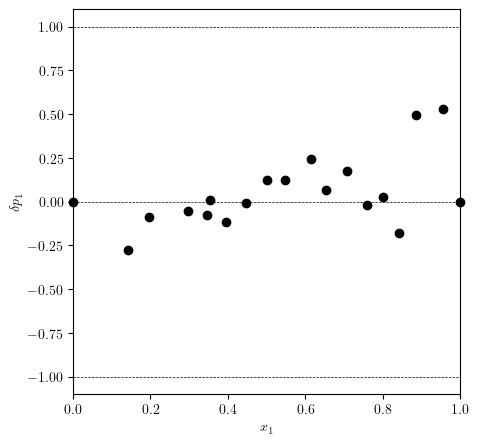

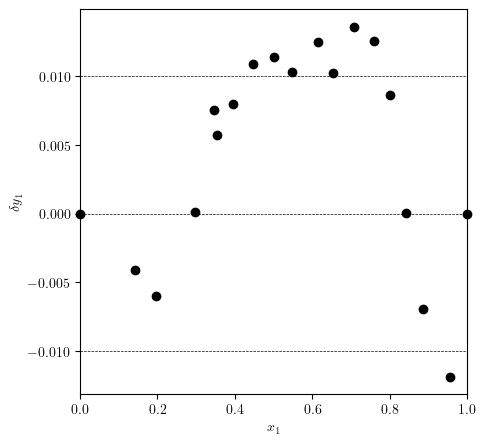

p/kPa = 50.0
N = 1
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 0.7207653634064247
A1 = -0.06751843914600371
A2 = 0.0
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.17618930684155448
AAD(y1) = 0.00381682029300738
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.15618518392434963
AAD(x1) = 0.004286278075654532
------------------------------------------


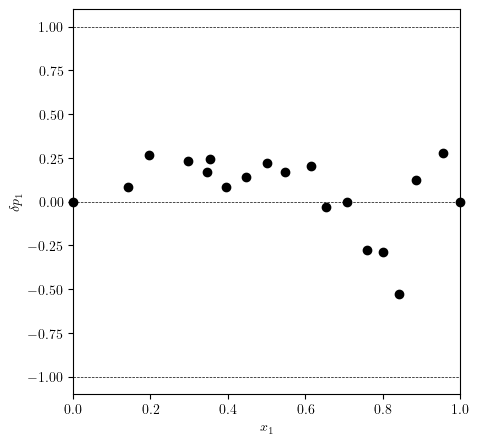

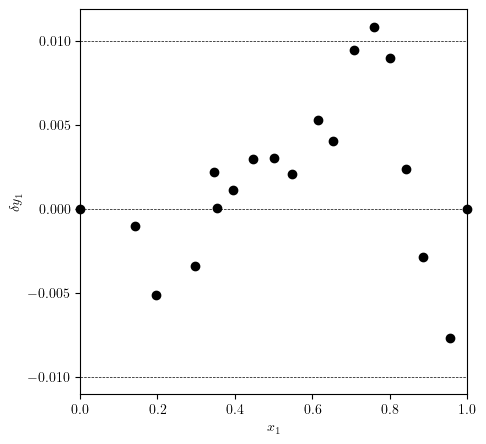

p/kPa = 50.0
N = 2
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 0.704234733007756
A1 = -0.06475439275094097
A2 = -0.03663859286553734
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.16494673055399656
AAD(y1) = 0.003130282120330167
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.15449726421689597
AAD(x1) = 0.0037875512234645803
------------------------------------------


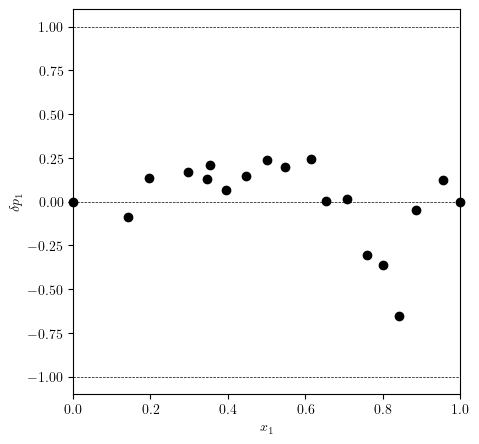

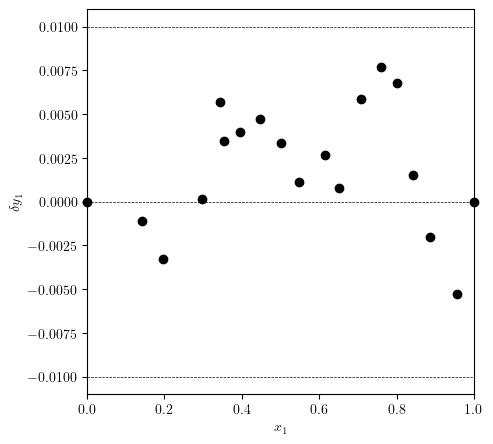

p/kPa = 50.0
N = 3
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 0.7066412635102852
A1 = -0.09433053813417655
A2 = -0.029368991618813664
A3 = -0.028240593902572417
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.14885401070933457
AAD(y1) = 0.003187536766429161
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.16797177627020637
AAD(x1) = 0.00396925070001536
------------------------------------------


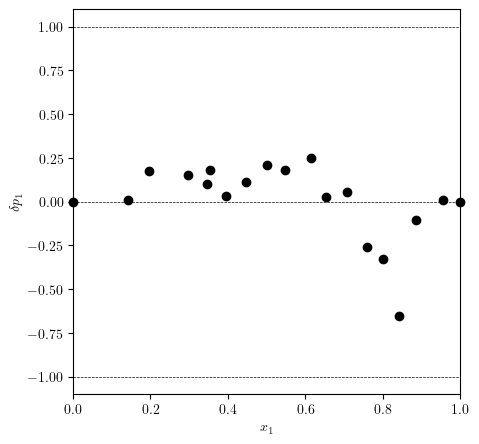

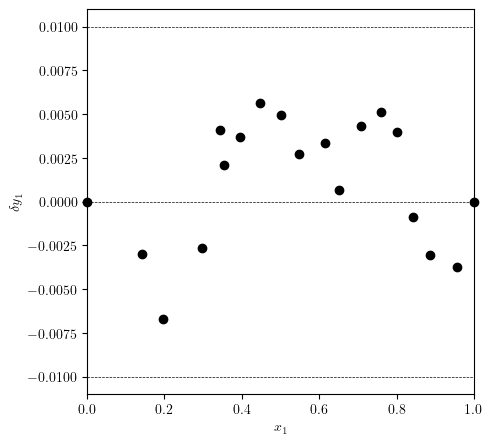

p/kPa = 50.0
N = 4
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 0.6891013020734874
A1 = -0.07925501670191684
A2 = -0.0830330247396088
A3 = -0.013727910104866806
A4 = -0.03538983940331103
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.14078873609737938
AAD(y1) = 0.002791162991976906
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.1696175230321427
AAD(x1) = 0.0033818116586306593
------------------------------------------


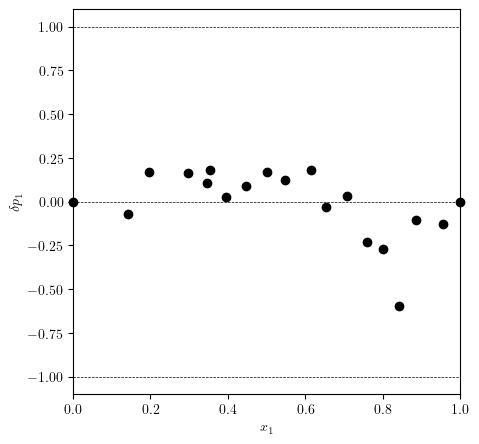

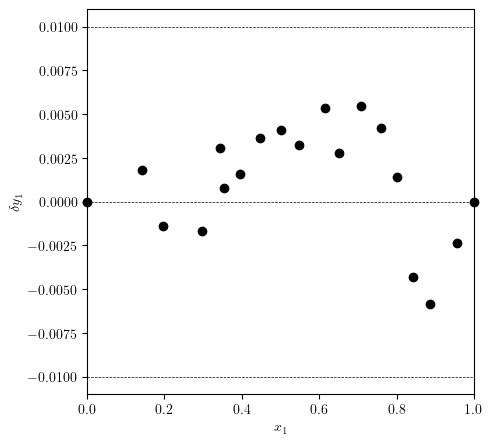

In [160]:
params50 = VLEgamphi(mix, "Legendre", method, Texp50, pexp50/100, Xexp50, Yexp50, "SLSQP", etaij, A0=[1, 0, 0, 0, 0])

********************************************************************************
                RESULTS FROM FREDENSLUND'S CONSISTENCY TEST                     
********************************************************************************
p/kPa = 75.0
N = 0
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 0.6354698958474307
A1 = 0.0
A2 = 0.0
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.29000708830371785
AAD(y1) = 0.007692087374952063
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.30289441078471124
AAD(x1) = 0.009722864077662142
------------------------------------------


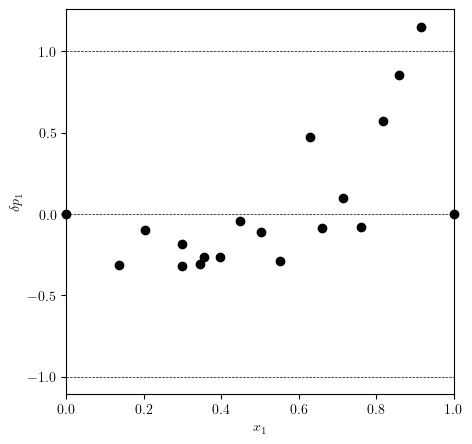

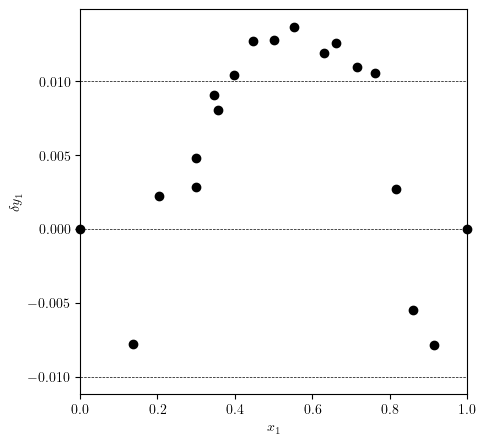

p/kPa = 75.0
N = 1
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 0.6354988488765848
A1 = -0.08684079895229624
A2 = 0.0
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.24721912885459335
AAD(y1) = 0.0027037564566177157
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.20876029526106787
AAD(x1) = 0.0031369591201722688
------------------------------------------


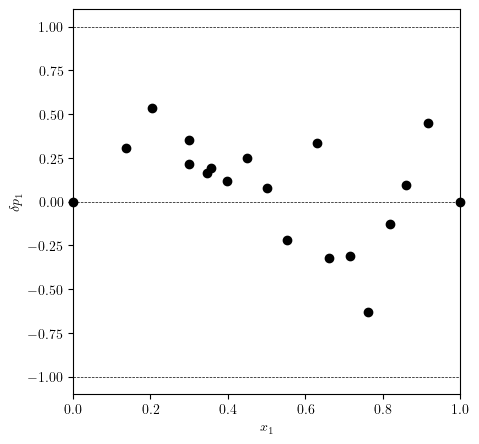

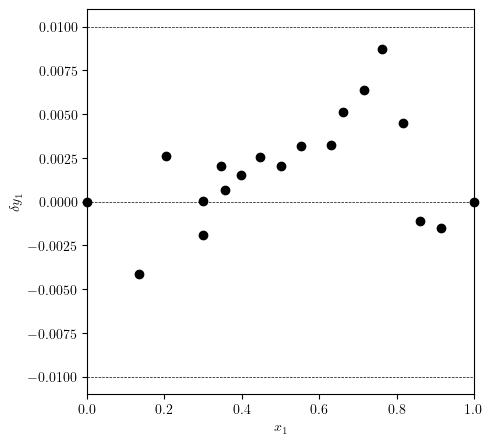

p/kPa = 75.0
N = 2
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 0.6207719364353564
A1 = -0.0871051721687432
A2 = -0.032221062812727415
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.20673845326454154
AAD(y1) = 0.0025208195618290044
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.18815750061424996
AAD(x1) = 0.003179913612063615
------------------------------------------


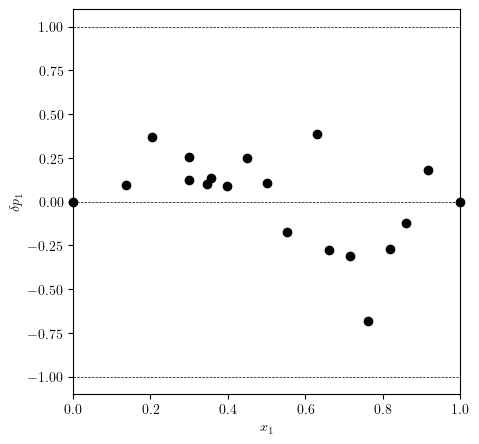

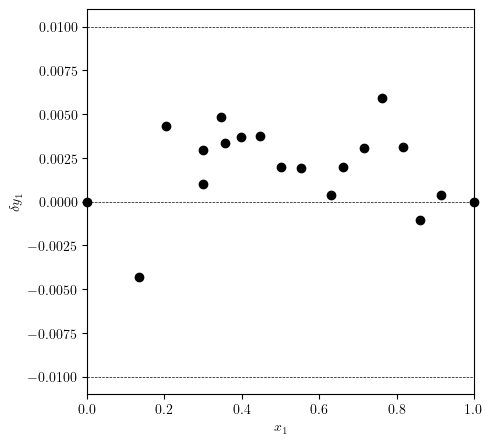

p/kPa = 75.0
N = 3
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 0.6217735926426561
A1 = -0.11378787928681758
A2 = -0.028879135459567884
A3 = -0.026272357601964193
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.1877863149135388
AAD(y1) = 0.0021597965185110035
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.19471132059925944
AAD(x1) = 0.0027746604385178453
------------------------------------------


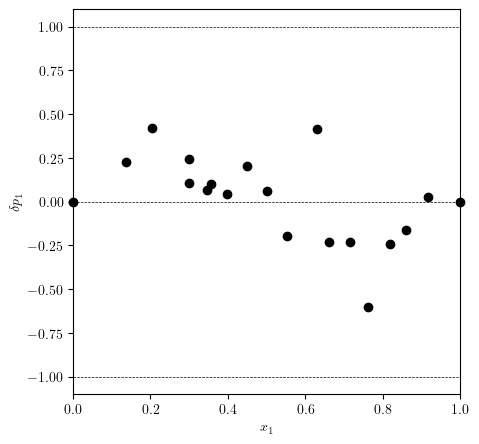

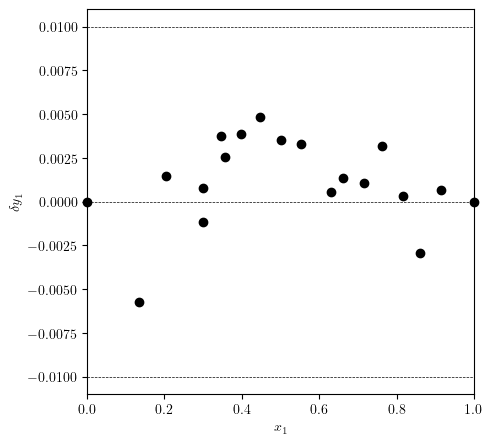

p/kPa = 75.0
N = 4
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 0.6117291205863952
A1 = -0.10882028949173059
A2 = -0.05882352305814813
A3 = -0.02070291499196462
A4 = -0.019117521898878102
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.18097135784076748
AAD(y1) = 0.002188996511109621
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.19074565697441906
AAD(x1) = 0.0027302357797466697
------------------------------------------


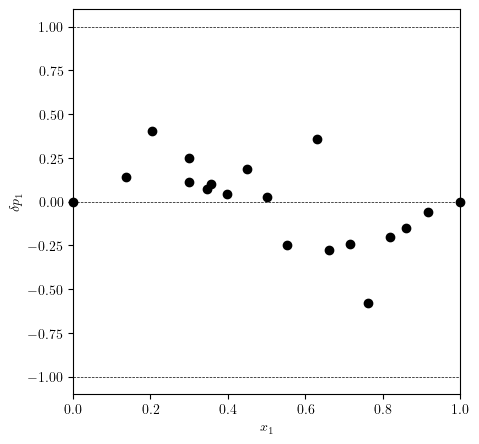

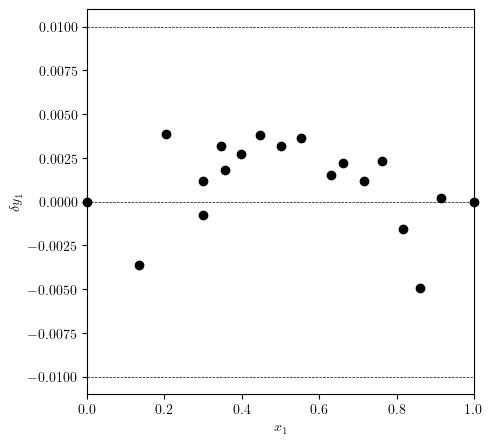

In [161]:
params75 = VLEgamphi(mix, "Legendre", method, Texp75, pexp75/100, Xexp75, Yexp75, "SLSQP", etaij, A0=[1, 0, 0, 0, 0])

********************************************************************************
                RESULTS FROM FREDENSLUND'S CONSISTENCY TEST                     
********************************************************************************
p/kPa = 94.0
N = 0
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 0.579031254939968
A1 = 0.0
A2 = 0.0
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.5447966744889448
AAD(y1) = 0.007323023312598409
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.4907442009968399
AAD(x1) = 0.008892685075932792
------------------------------------------


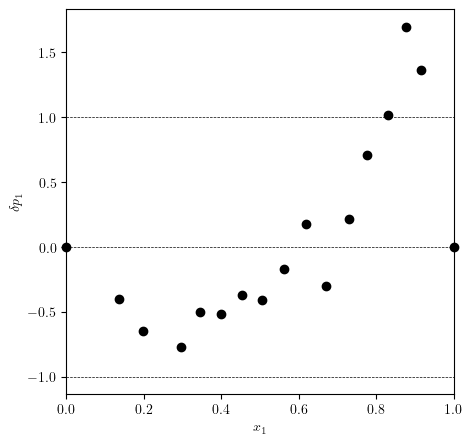

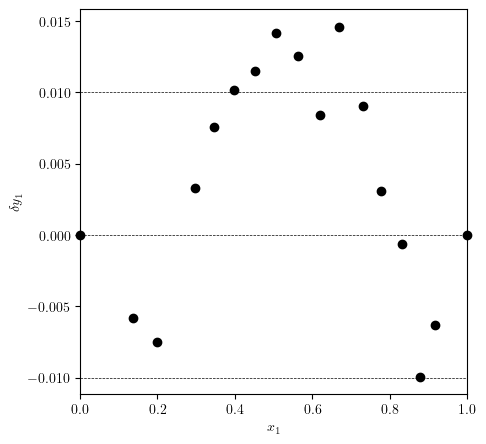

p/kPa = 94.0
N = 1
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 0.5821443829985188
A1 = -0.10173757792808284
A2 = 0.0
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.22639750273678333
AAD(y1) = 0.0020032140065768663
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.18805931136244944
AAD(x1) = 0.002173375089992615
------------------------------------------


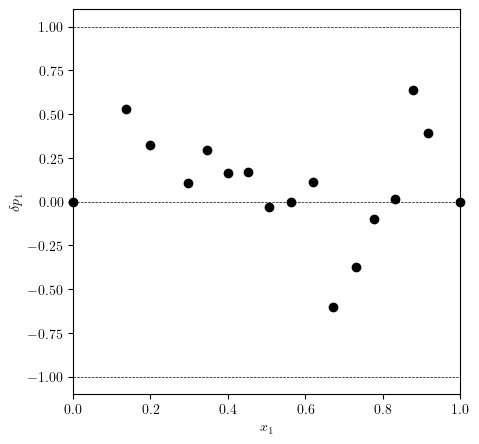

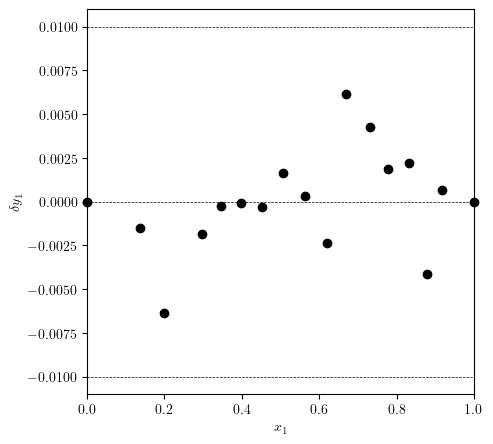

p/kPa = 94.0
N = 2
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 0.5660122900716433
A1 = -0.09824902705245639
A2 = -0.03591274142574408
A3 = 0.0
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.15591243698467513
AAD(y1) = 0.002027886981851404
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.14205415578504232
AAD(x1) = 0.0023749860572242552
------------------------------------------


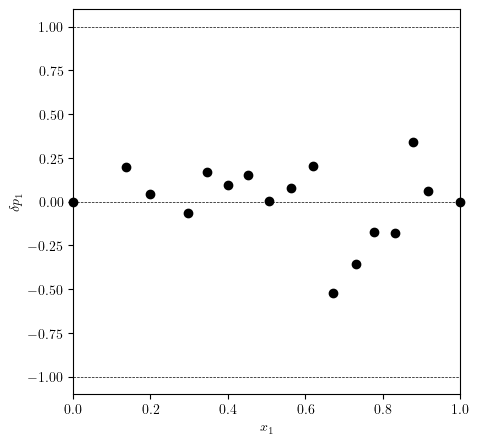

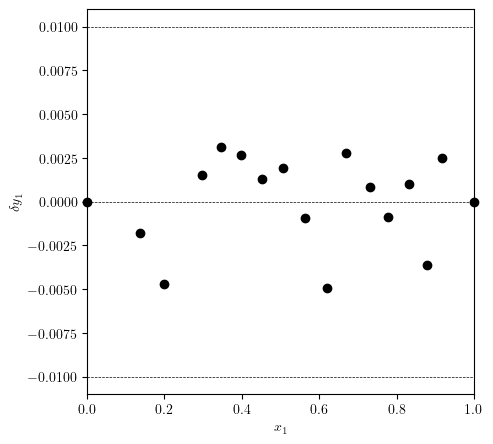

p/kPa = 94.0
N = 3
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 0.5663820576105681
A1 = -0.097681866821318
A2 = -0.03510033972786123
A3 = 0.000559809707344401
A4 = 0.0
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.15762538272986001
AAD(y1) = 0.002014294311893857
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.1422995476464765
AAD(x1) = 0.0023548435952255764
------------------------------------------


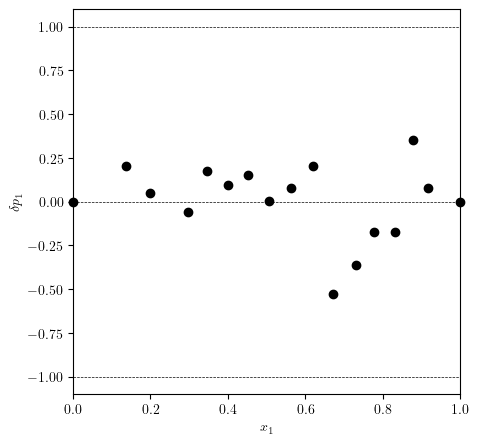

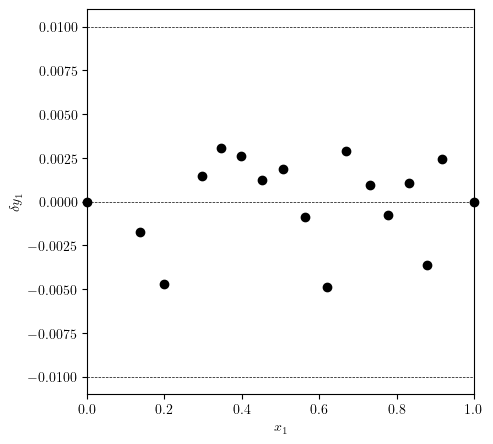

p/kPa = 94.0
N = 4
------------------------------------------
Coefficients of Legendre polynomials:
------------------------------------------
A0 = 0.5584852255923171
A1 = -0.09375973020563702
A2 = -0.06204720608001561
A3 = 0.005825444055652878
A4 = -0.018007789980529307
------------------------------------------
Bubble-point statistics:
------------------------------------------
AAD(p)/kPa = 0.14020251982110746
AAD(y1) = 0.0017033765718707777
------------------------------------------
Dew-point statistics:
------------------------------------------
AAD(p)/kPa = 0.12065132988066957
AAD(x1) = 0.00188706465029546
------------------------------------------


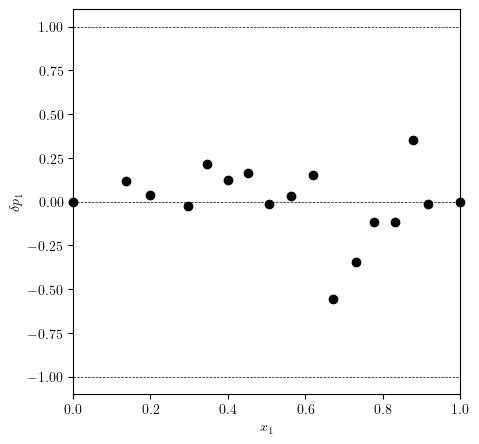

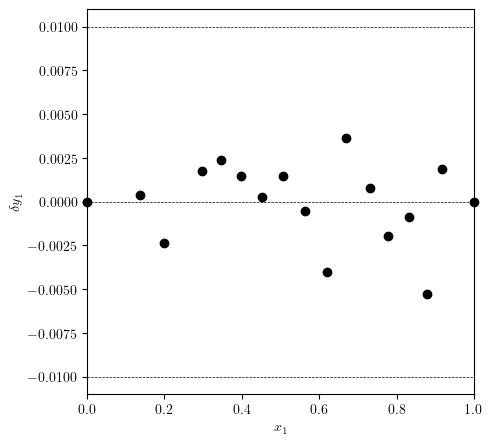

In [162]:
params94 = VLEgamphi(mix, "Legendre", method, Texp94, pexp94/100, Xexp94, Yexp94, "SLSQP", etaij, A0=[1, 0, 0, 0, 0])

In [163]:
n = 3
x1 = np.linspace(0.0, 1.0, num = 100)
z = len(x1)
#VLE calculations: 50.00 kPa
p = 50/100
T_50 = np.zeros(z)
y1_50 = np.zeros(z)
gE_50 = np.zeros(z)
gam1_50 = np.zeros(z)
gam2_50 = np.zeros(z)
for i in range(z):
    T_50[i], y1_50[i], gam1_50[i], gam2_50[i], gE_50[i] = Tybubble(mix, params50[n,:], "Legendre", method, p, x1[i], n=n, mixij=etaij, t0=[330])

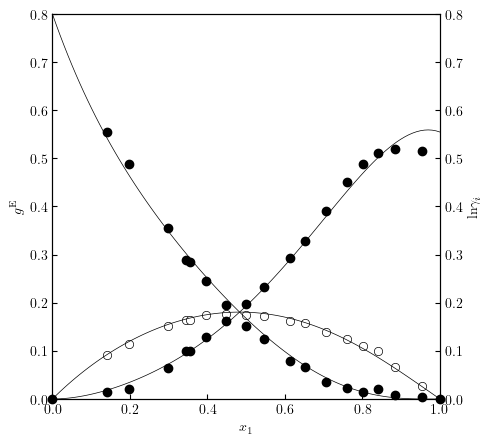

In [164]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
fig, ax1 = plt.subplots(figsize=(5,5))
ax1.tick_params(direction='in')
ax1.set_xlabel(r'$x_{1}$')
ax1.set_ylabel(r'$g^{\mathrm{E}}$')
ax1.scatter(Xexp50[0], exp50[2], color='black', facecolors="white", edgecolors='black', linewidth=0.5)
ax1.plot(x1, gE_50, color='black', linewidth=0.5, clip_on=False, zorder=10)
ax1.set_ylim([0, 0.8])

ax2 = ax1.twinx()
ax2.tick_params(direction='in')
ax2.scatter(Xexp50[0], np.log(exp50[0]), color='black', clip_on=False, zorder=10)
ax2.scatter(Xexp50[0], np.log(exp50[1]), color='black', clip_on=False, zorder=10)
ax2.plot(x1, np.log(gam1_50), clip_on=False, color='black', linewidth=0.5, zorder=10)
ax2.plot(x1, np.log(gam2_50), clip_on=False, color='black', linewidth=0.5, zorder=10)
ax2.set_ylabel(r'$\mathrm{ln}\gamma_{i}$')
ax2.set_ylim([0, 0.8])

plt.xlim([0, 1])
plt.savefig("leg50.pdf", format="pdf", bbox_inches="tight")
plt.show()

/var/folders/9v/drtvpwln451d5xz3qjlrzyvm0000gn/T/ipykernel_48345/2557187635.py:5: RuntimeWarning: invalid value encountered in true_divide
  plt.plot(x1, gE_50/x1/(1-x1), linewidth=0.5, color="black")
/var/folders/9v/drtvpwln451d5xz3qjlrzyvm0000gn/T/ipykernel_48345/2557187635.py:5: RuntimeWarning: divide by zero encountered in true_divide
  plt.plot(x1, gE_50/x1/(1-x1), linewidth=0.5, color="black")


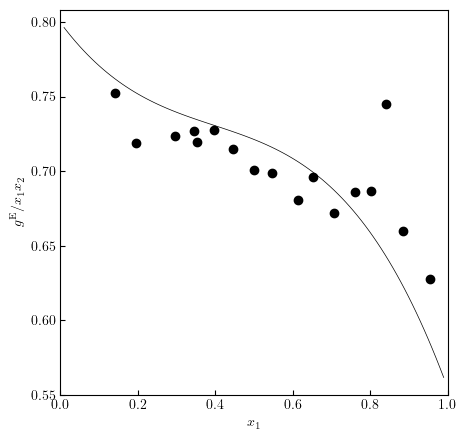

In [165]:
plt.figure(figsize=(5,5))
plt.tick_params(direction='in')
gEx50 = exp50[2]/Xexp50[0]/Xexp50[1]
plt.scatter(Xexp50[0], gEx50, color="black")
plt.plot(x1, gE_50/x1/(1-x1), linewidth=0.5, color="black")
plt.xlabel("$x_{1}$")
plt.xlim([0.0, 1.0])
plt.ylabel("$g^{\mathrm{E}}/x_{1}x_{2}$")
plt.show()

In [166]:
#VLE calculations: 75.00 kPa
p = 75/100
T_75 = np.zeros(z)
y1_75 = np.zeros(z)
gE_75 = np.zeros(z)
gam1_75 = np.zeros(z)
gam2_75 = np.zeros(z)
for i in range(z):
    T_75[i], y1_75[i], gam1_75[i], gam2_75[i], gE_75[i] = Tybubble(mix, params75[n,:], "Legendre", method, p, x1[i], n=n, mixij=etaij, t0=[340])

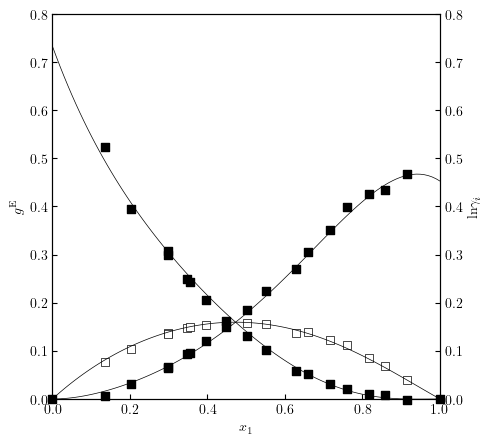

In [167]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
fig, ax1 = plt.subplots(figsize=(5,5))
ax1.tick_params(direction='in')
ax1.set_xlabel(r'$x_{1}$')
ax1.set_ylabel(r'$g^{\mathrm{E}}$')
ax1.scatter(Xexp75[0], exp75[2], marker='s', color='black', facecolors="white", edgecolors='black', linewidth=0.5)
ax1.plot(x1, gE_75, color='black', linewidth=0.5, clip_on=False, zorder=10)
ax1.set_ylim([0, 0.8])

ax2 = ax1.twinx()
ax2.tick_params(direction='in')
ax2.scatter(Xexp75[0], np.log(exp75[0]), marker='s', color='black', clip_on=False, zorder=10)
ax2.scatter(Xexp75[0], np.log(exp75[1]), marker='s', color='black', clip_on=False, zorder=10)
ax2.plot(x1, np.log(gam1_75), clip_on=False, color='black', linewidth=0.5, zorder=10)
ax2.plot(x1, np.log(gam2_75), clip_on=False, color='black', linewidth=0.5, zorder=10)
ax2.set_ylabel(r'$\mathrm{ln}\gamma_{i}$')
ax2.set_ylim([0, 0.8])

plt.xlim([0, 1])
plt.savefig("leg75.pdf", format="pdf", bbox_inches="tight")
plt.show()

/var/folders/9v/drtvpwln451d5xz3qjlrzyvm0000gn/T/ipykernel_48345/1516806817.py:5: RuntimeWarning: invalid value encountered in true_divide
  plt.plot(x1, gE_75/x1/(1-x1), linewidth=0.5, color="black")
/var/folders/9v/drtvpwln451d5xz3qjlrzyvm0000gn/T/ipykernel_48345/1516806817.py:5: RuntimeWarning: divide by zero encountered in true_divide
  plt.plot(x1, gE_75/x1/(1-x1), linewidth=0.5, color="black")


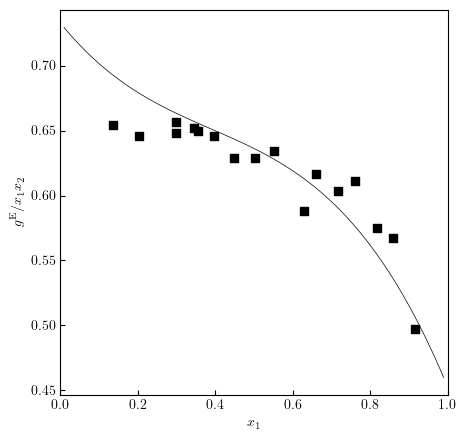

In [168]:
plt.figure(figsize=(5,5))
plt.tick_params(direction='in')
gEx75 = exp75[2]/Xexp75[0]/Xexp75[1]
plt.scatter(Xexp75[0], gEx75, color="black", marker='s')
plt.plot(x1, gE_75/x1/(1-x1), linewidth=0.5, color="black")
plt.xlim([0.0, 1.0])
plt.xlabel("$x_{1}$")
plt.ylabel("$g^{\mathrm{E}}/x_{1}x_{2}$")
plt.show()

In [169]:
#VLE calculations: 94.00 kPa
p = 94/100
T_94 = np.zeros(z)
y1_94 = np.zeros(z)
gE_94 = np.zeros(z)
gam1_94 = np.zeros(z)
gam2_94 = np.zeros(z)
for i in range(z):
    T_94[i], y1_94[i], gam1_94[i], gam2_94[i], gE_94[i] = Tybubble(mix, params94[n,:], "Legendre", method, p, x1[i], n=n, mixij=etaij, t0=[340])

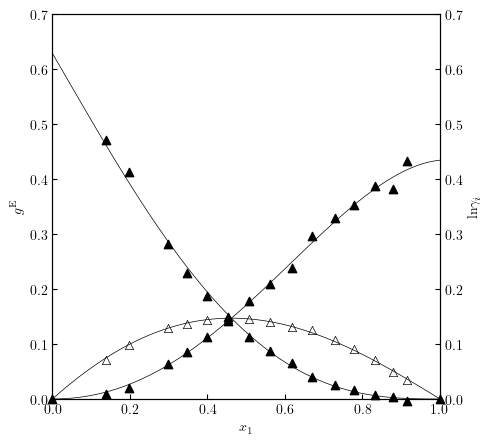

In [170]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
fig, ax1 = plt.subplots(figsize=(5,5))
ax1.tick_params(direction='in')
ax1.set_xlabel(r'$x_{1}$')
ax1.set_ylabel(r'$g^{\mathrm{E}}$')
ax1.scatter(Xexp94[0], exp94[2], marker='^', color='black', facecolors="white", edgecolors='black', linewidth=0.5)
ax1.plot(x1, gE_94, color='black', linewidth=0.5, clip_on=False, zorder=10)
ax1.set_ylim([0, 0.7])

ax2 = ax1.twinx()
ax2.tick_params(direction='in')
ax2.scatter(Xexp94[0], np.log(exp94[0]), marker='^', color='black', clip_on=False, zorder=10)
ax2.scatter(Xexp94[0], np.log(exp94[1]), marker='^', color='black', clip_on=False, zorder=10)
ax2.plot(x1, np.log(gam1_94), clip_on=False, color='black', linewidth=0.5, zorder=10)
ax2.plot(x1, np.log(gam2_94), clip_on=False, color='black', linewidth=0.5, zorder=10)
ax2.set_ylabel(r'$\mathrm{ln}\gamma_{i}$')
ax2.set_ylim([0, 0.7])

plt.xlim([0, 1])
plt.savefig("leg94.pdf", format="pdf", bbox_inches="tight")
plt.show()

/var/folders/9v/drtvpwln451d5xz3qjlrzyvm0000gn/T/ipykernel_48345/2598322357.py:5: RuntimeWarning: invalid value encountered in true_divide
  plt.plot(x1, gE_94/x1/(1-x1), linewidth=0.5, color="black")
/var/folders/9v/drtvpwln451d5xz3qjlrzyvm0000gn/T/ipykernel_48345/2598322357.py:5: RuntimeWarning: divide by zero encountered in true_divide
  plt.plot(x1, gE_94/x1/(1-x1), linewidth=0.5, color="black")


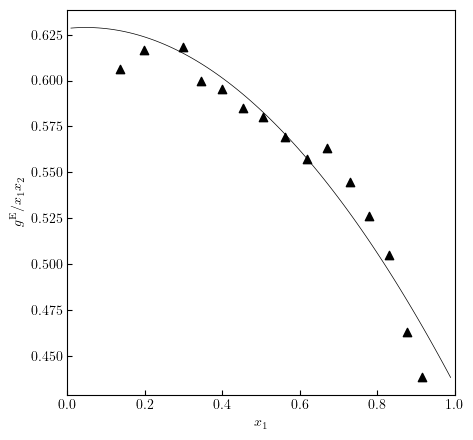

In [171]:
plt.figure(figsize=(5,5))
plt.tick_params(direction='in')
gEx94 = exp94[2]/Xexp94[0]/Xexp94[1]
plt.scatter(Xexp94[0], gEx94, color="black", marker='^')
plt.plot(x1, gE_94/x1/(1-x1), linewidth=0.5, color="black")
plt.xlim([0.0, 1.0])
plt.xlabel("$x_{1}$")
plt.ylabel("$g^{\mathrm{E}}/x_{1}x_{2}$")
plt.show()

In [172]:
#VLE calculations: 94.00 kPa
p = 101.3/100
T_101 = np.zeros(z)
y1_101 = np.zeros(z)
gE_101 = np.zeros(z)
gam1_101 = np.zeros(z)
gam2_101 = np.zeros(z)
for i in range(z):
    T_101[i], y1_101[i], gam1_101[i], gam2_101[i], gE_101[i] = Tybubble(mix, params94[n,:], "Legendre", method, p, x1[i], n=n, mixij=etaij, t0=[390])

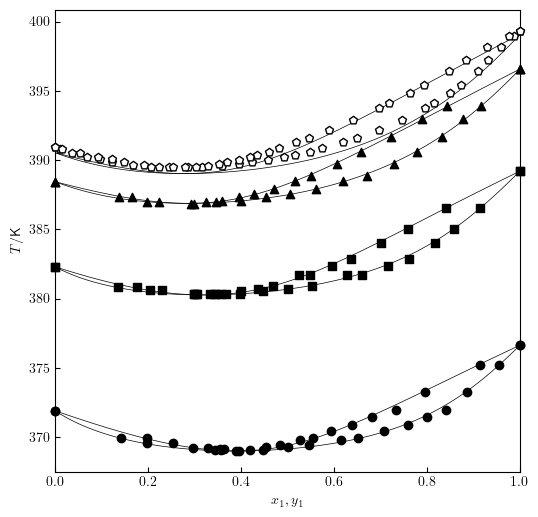

In [173]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
fig = plt.subplots(figsize=(6,6))
plt.tick_params(direction='in')
plt.scatter(Xexp50[0], Texp50, color='black', clip_on=False, zorder=10)
plt.scatter(Yexp50[0], Texp50, color='black', clip_on=False, zorder=10)
plt.scatter(Xexp75[0], Texp75, marker='s', color='black', clip_on=False, zorder=10)
plt.scatter(Yexp75[0], Texp75, marker='s', color='black', clip_on=False, zorder=10)
plt.scatter(Xexp94[0], Texp94, marker='^', color='black', clip_on=False, zorder=10)
plt.scatter(Yexp94[0], Texp94, marker='^', color='black', clip_on=False, zorder=10)
plt.scatter(Xexp101[0], Texp101, marker='p', facecolors="white", edgecolors='black', clip_on=False, zorder=10)
plt.scatter(Yexp101[0], Texp101, marker='p', facecolors="white", edgecolors='black', clip_on=False, zorder=10)
plt.plot(x1, T_50, color='black', linewidth='0.5')
plt.plot(y1_50, T_50, color='black', linewidth='0.5')
plt.plot(x1, T_75, color='black', linewidth='0.5')
plt.plot(y1_75, T_75, color='black', linewidth='0.5')
plt.plot(x1, T_94, color='black', linewidth='0.5')
plt.plot(y1_94, T_94, color='black', linewidth='0.5')
plt.plot(x1, T_101, color='black', linewidth='0.5')
plt.plot(y1_101, T_101, color='black', linewidth='0.5')
plt.xlim([0, 1.0])
plt.xlabel(r'$x_{1}, y_{1}$')
plt.ylabel(r'$T$/K')
plt.savefig("VLE.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [174]:
k = len(Texp50)
Wilson50 = VLEgamphi(mix, "Wilson", method, Texp50, pexp50/100, Xexp50, Yexp50, "Nelder-Mead", mixij=etaij, A0=[-1000, 1000, 0, 0, 0])
NRTL50 = VLEgamphi(mix, "NRTL", method, Texp50, pexp50/100, Xexp50, Yexp50, "Nelder-Mead", mixij=etaij, A0=[1000, -1000, 0, 0, 0])
UNIQUAC50 = VLEgamphi(mix, "UNIQUAC", method, Texp50[1:k-1], pexp50[1:k-1]/100, Xexp50[:,1:k-1], Yexp50[:,1:k-1], "Nelder-Mead", mixij=etaij, A0=[-100, -100, 0, 0, 0])

********************************************************************************
           ISOBARIC VLE MODELING BASED ON LOCAL COMPOSITION MODELS              
********************************************************************************
p/kPa = 50.0
Model = Wilson
Method = Ideal
------------------------------------------
Energy difference parameters:
------------------------------------------
de12 = 119.97673638534941
de21 = 184.14762216093345
------------------------------------------
Bubble-point calculations:
------------------------------------------
AAD(p)/kPa = 0.1778723654888587
AAD(y1) = 0.004340555525570945
------------------------------------------
Dew-point calculations:
------------------------------------------
AAD(p)/kPa = 0.16210890310887044
AAD(x1) = 0.004950546474526549
------------------------------------------
********************************************************************************
           ISOBARIC VLE MODELING BASED ON LOCAL COMPOSITION MODELS      

In [175]:
k = len(Texp75)
Wilson75 = VLEgamphi(mix, "Wilson", method, Texp75, pexp75/100, Xexp75, Yexp75, "Nelder-Mead", mixij=etaij, A0=[-1000, 1000, 0, 0, 0]) 
NRTL75 = VLEgamphi(mix, "NRTL", method, Texp75, pexp75/100, Xexp75, Yexp75, "Nelder-Mead", mixij=etaij, A0=[1000, -1000, 0, 0, 0]) 
UNIQUAC75 = VLEgamphi(mix, "UNIQUAC", method, Texp75[1:k-1], pexp75[1:k-1]/100, Xexp75[:,1:k-1], Yexp75[:,1:k-1], "Nelder-Mead", mixij=etaij, A0=[-100, -100, 0, 0, 0])

********************************************************************************
           ISOBARIC VLE MODELING BASED ON LOCAL COMPOSITION MODELS              
********************************************************************************
p/kPa = 75.0
Model = Wilson
Method = Ideal
------------------------------------------
Energy difference parameters:
------------------------------------------
de12 = 138.43215123988676
de21 = 143.50404702945877
------------------------------------------
Bubble-point calculations:
------------------------------------------
AAD(p)/kPa = 0.253068413621065
AAD(y1) = 0.0032485642509819737
------------------------------------------
Dew-point calculations:
------------------------------------------
AAD(p)/kPa = 0.21585459759099027
AAD(x1) = 0.0038088605578317602
------------------------------------------
********************************************************************************
           ISOBARIC VLE MODELING BASED ON LOCAL COMPOSITION MODELS     

In [176]:
k = len(Texp94)
Wilson94 = VLEgamphi(mix, "Wilson", method, Texp94, pexp94/100, Xexp94, Yexp94, "Nelder-Mead", mixij=etaij, A0=[-1000, 1000, 0, 0, 0])
NRTL94 = VLEgamphi(mix, "NRTL", method, Texp94, pexp94/100, Xexp94, Yexp94, "Nelder-Mead", mixij=etaij, A0=[1000, -1000, 0, 0, 0])
UNIQUAC94 = VLEgamphi(mix, "UNIQUAC", method, Texp94[1:k-1], pexp94[1:k-1]/100, Xexp94[:,1:k-1], Yexp94[:,1:k-1], "Nelder-Mead", mixij=etaij, A0=[-100, -100, 0, 0, 0])

********************************************************************************
           ISOBARIC VLE MODELING BASED ON LOCAL COMPOSITION MODELS              
********************************************************************************
p/kPa = 94.0
Model = Wilson
Method = Ideal
------------------------------------------
Energy difference parameters:
------------------------------------------
de12 = 161.19909573514974
de21 = 110.6267502576348
------------------------------------------
Bubble-point calculations:
------------------------------------------
AAD(p)/kPa = 0.2500324810963478
AAD(y1) = 0.0025061188154314007
------------------------------------------
Dew-point calculations:
------------------------------------------
AAD(p)/kPa = 0.21383629720667097
AAD(x1) = 0.0027845183107568995
------------------------------------------
********************************************************************************
           ISOBARIC VLE MODELING BASED ON LOCAL COMPOSITION MODELS     

In [177]:
IFT1 = pd.read_excel("DEC-1butol.xlsx", sheet_name="IFT1")
Texp1 = IFT1['T/K'].to_numpy()
IFTexp1 = IFT1['st/mN.m'].to_numpy()
IFT1.head(n=4)

,T/K,st/mN.m
0,298.15,25.2


In [178]:
IFT2 = pd.read_excel("DEC-1butol.xlsx", sheet_name="IFT2")
Texp2 = IFT2['T/K'].to_numpy()
IFTexp2 = IFT2['st/mN.m'].to_numpy()
IFT2.head(n=4)

,T/K,st/mN.m
0,298.15,24.37


In [179]:
IFT = pd.read_excel("DEC-1butol.xlsx", sheet_name="IFT")
x1exp = IFT['x1'].to_numpy()
IFTexp = IFT['st/mN.m'].to_numpy()
IFT.head(n=4)

,x1,st/mN.m
0,0.000,24.37
1,0.045,24.49
2,0.092,24.68
3,0.194,24.97


In [180]:
def Chunxi_obj(W, component1, component2, x1exp, stexp, T, params):
    
    x2 = 1-x1exp
    vlsat1 = component1.vlrackett(T)
    vlsat2 = component2.vlrackett(T)
    A12 = vlsat2/vlsat1*np.exp(-params[0]/8.314/T)
    A21 = vlsat1/vlsat2*np.exp(-params[1]/8.314/T)
    dA12 = -A12/8.314/T*W[0]
    dA21 = -A21/8.314/T*W[1]
    st = x1exp*stexp[-1]+x2*stexp[0]-8.314*T*(x1exp*x2/(x1exp+x2*A12)*dA12+x2*x1exp/(x1exp*A21+x2)*dA21)*1000
    
    AAD = 100/len(stexp)*np.sum(abs(st-stexp)/stexp)
    
    return AAD

def fit_Chunxi(component1, component2, x1exp, stexp, T, params, w0=[0, 0]):
    from scipy.optimize import minimize
    fit = minimize(Chunxi_obj, w0, args=(component1, component2, x1exp, stexp, T, params), method='SLSQP')
    return fit

In [181]:
Wilson94 = Wilson94*8.314

In [182]:
T = 298.15
paramsChunxi = fit_Chunxi(chem1, chem2, x1exp, IFTexp, T, Wilson94, w0=[0, 0])
print(paramsChunxi)
print("")

     fun: 0.10051979950606525
     jac: array([-41.41759772, -61.22643837])
 message: 'Optimization terminated successfully'
    nfev: 66
     nit: 14
    njev: 14
  status: 0
 success: True
       x: array([0.0012197 , 0.00205161])



In [183]:
def Chunxist(z, component1, component2, stexp, T, params, dparams):
    
    vlsat1 = component1.vlrackett(T)
    vlsat2 = component2.vlrackett(T)
    A12 = vlsat2/vlsat1*np.exp(-params[0]/8.314/T)
    A21 = vlsat1/vlsat2*np.exp(-params[1]/8.314/T)
    dA12 = -A12/8.314/T*dparams[0]
    dA21 = -A21/8.314/T*dparams[1]
    st = z*stexp[-1]+(1-z)*stexp[0]-8.314*T*(z*(1-z)/(z+(1-z)*A12)*dA12+(1-z)*z/(z*A21+(1-z))*dA21)*1000
    
    return st

In [184]:
x1 = np.linspace(0.00001, 0.99999, num = 100)
n = len(x1)
stmix = np.zeros_like(x1)
for i in range(n):
    stmix[i] = Chunxist(x1[i], chem1, chem2, IFTexp, T, Wilson94, paramsChunxi.x)

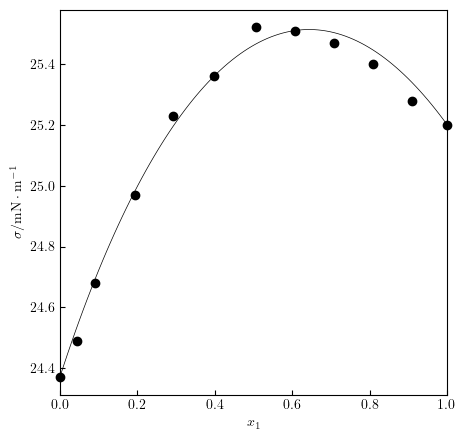

In [185]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.figure(figsize=(5,5))
plt.tick_params(direction='in')
plt.scatter(x1exp, IFTexp, color="black", clip_on=False, zorder=10)
plt.plot(x1, stmix, color="black", linewidth=0.5)
plt.xlim([0.0, 1.0])
plt.xlabel(r"$x_{1}$")
plt.ylabel(r"$\sigma/\mathrm{mN}\cdot \mathrm{m}^{-1}$")
plt.savefig("stmix_chunxi.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [186]:
n = len(x1exp)
stmix = np.zeros_like(x1exp)
for i in range(n):
    stmix[i] = Chunxist(x1exp[i], chem1, chem2, IFTexp, T, Wilson94/8.314, paramsChunxi.x)

AAPD = 100/n*np.sum(abs(stmix-IFTexp)/IFTexp)
print("AAPD/%: ", AAPD)

AAPD/%:  0.3658332284129911


In [187]:
Ant1 = fit_ant(Tsat1, psat1/100, "ln", x0=[0, 0, 0])
print(Ant1)

      fun: 7.81012842554441e-05
 hess_inv: array([[ 3.57895654e+01,  1.35297829e+04, -6.85809821e+00],
       [ 1.35297829e+04,  5.11857425e+06, -2.61254133e+03],
       [-6.85809821e+00, -2.61254133e+03,  2.44500064e+00]])
      jac: array([-1.78751907e-06,  5.37147571e-09,  5.68470568e-08])
  message: 'Optimization terminated successfully.'
     nfev: 148
      nit: 35
     njev: 37
   status: 0
  success: True
        x: array([ 1.18002476e+01,  4.67957269e+03, -2.07489684e+00])


In [188]:
import phasepy
import math
from phasepy import component, mixture
# thermophysical properties from DIPPR 801 (2025)
comp1 = component(name=chem1.name, Tc=chem1.Tc, Pc=chem1.Pc, Zc=chem1.Zc, w=w1, Mw=chem1.Mw,
                 Ant=Ant1.x, ri=chem1.ri, qi=chem1.qi)
comp2 = component(name=chem2.name, Tc=chem2.Tc, Pc=chem2.Pc, Zc=chem2.Zc, w=w2, Mw=chem2.Mw,
                 Ant=[(6.4552*math.log(10)-math.log(100)), 1285.522*math.log(10), -101.6256], ri=chem2.ri, qi=chem2.qi)
mix = mixture(comp1, comp2)

In [189]:
#Fitting ksv for PRSV EoS
from phasepy.fit import fit_ksv
ksv1 = fit_ksv(comp1, Tsat1, psat1/100)
ksv2 = fit_ksv(comp2, Tsat2, psat2/100)

In [190]:
comp1 = component(name=chem1.name, Tc=chem1.Tc, Pc=chem1.Pc, Zc=chem1.Zc, w=w1, Mw=chem1.Mw, ksv=ksv1.x,
                 Ant=Ant1.x, ri=chem1.ri, qi=chem1.qi)
comp2 = component(name=chem2.name, Tc=chem2.Tc, Pc=chem2.Pc, Zc=chem2.Zc, w=w2, Mw=chem2.Mw, ksv=ksv2.x,
                 Ant=[(6.4552*math.log(10)-math.log(100)), 1285.522*math.log(10), -101.6256], ri=chem2.ri, qi=chem2.qi)
mix = mixture(comp1, comp2)

In [191]:
t = np.linspace(350, 450, num=101)
n = len(t)
from phasepy import prsveos
eos1 = prsveos(comp1)
eos2 = prsveos(comp2)
psatpr1 = np.zeros(n)
psatpr2 = np.zeros(n)
vlsatpr1 = np.zeros(n)
vlsatpr2 = np.zeros(n)
vvsatpr1 = np.zeros(n)
vvsatpr2 = np.zeros(n)
for i in range(n):
    psatpr1[i], vlsatpr1[i], vvsatpr1[i] = eos1.psat(t[i])
    psatpr2[i], vlsatpr2[i], vvsatpr2[i] = eos2.psat(t[i])

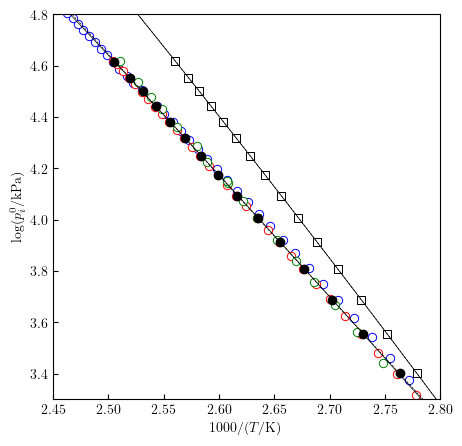

In [192]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.figure(figsize=(5,5))
plt.tick_params(direction='in')
plt.scatter(1000/dat1_Tsat1, np.log(dat1_psat1), edgecolors="blue", facecolors="white", linewidth=0.7)
plt.scatter(1000/dat2_Tsat1, np.log(dat2_psat1), edgecolors="red", facecolors="white", linewidth=0.7)
plt.scatter(1000/dat3_Tsat1, np.log(dat3_psat1), edgecolors="green", facecolors="white", linewidth=0.7)
plt.scatter(1000/Tsat1, np.log(psat1), color="black")
plt.scatter(1000/Tsat2, np.log(psat2), color="black", marker="s", edgecolors="black", facecolors="white", linewidth=0.7)
plt.plot(1000/t, np.log(pant1), color="black", linestyle="dashed", linewidth=0.5)
plt.plot(1000/t, np.log(pant2), color="black", linestyle="dashed", linewidth=0.5)
plt.plot(1000/t, np.log(psatpr1*100), color="black", linewidth=0.5)
plt.plot(1000/t, np.log(psatpr2*100), color="black", linewidth=0.5)
plt.xlim([2.45, 2.8])
plt.ylim([3.3, 4.8])
plt.xlabel(r"$1000/(T/\mathrm{K})$")
plt.ylabel(r"$\mathrm{log}(p^{0}_{i}/\mathrm{kPa})$")
plt.savefig("psat.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [193]:
from phasepy.fit import fit_kij
mixkij = mix.copy()
kij50 = fit_kij((-0.15, -0.05), prsveos, mixkij, datavle50)

In [194]:
kij75 = fit_kij((-0.15, -0.05), prsveos, mixkij, datavle75)

In [195]:
kij94 = fit_kij((-0.15, -0.05), prsveos, mixkij, datavle94)

In [196]:
#read dynamic viscosity data
import pandas as pd
DVIS1 = pd.read_excel("DEC-1butol.xlsx", sheet_name="DVIS1")
Texp1 = DVIS1['T/K'].to_numpy()
dvisexp1 = DVIS1['dvis/mPa.s'].to_numpy()
DVIS1.head(n=4)

,T/K,dvis/mPa.s
0,298.15,0.7211


In [197]:
DVIS2 = pd.read_excel("DEC-1butol.xlsx", sheet_name="DVIS2")
Texp2 = DVIS2['T/K'].to_numpy()
dvisexp2 = DVIS2['dvis/mPa.s'].to_numpy()
DVIS2.head(n=4)

,T/K,dvis/mPa.s
0,298.15,2.587


In [198]:
DVIS = pd.read_excel("DEC-1butol.xlsx", sheet_name="DVIS")
x1exp = DVIS['x1'].to_numpy()
dvisexp = DVIS['dvis/mPa.s'].to_numpy()
DVIS.head(n=4)

,x1,dvis/mPa.s
0,0.000,2.5870
1,0.048,2.1391
2,0.097,1.8644
3,0.194,1.4784


In [199]:
DVISCAN = pd.read_excel("DEC-1butol.xlsx", sheet_name="dvis_can")
x1exp_can = DVISCAN['x1'].to_numpy()
dvisexp_can = DVISCAN['dvis/mPa.s'].to_numpy()
DVISCAN.head(n=4)

,x1,dvis/mPa.s
0,0.0000,2.620
1,0.0519,2.203
2,0.0993,1.899
3,0.1996,1.445


In [200]:
def dvis_hs(component, T):
    '''
    This subroutine calculates the dynamic viscosity of a hard-sphere fluid according to the Chapman-Enskog theory.
    '''
    import math
    R = 83.14 # gas constant, bar.cm3/mol.K
    Na = 6.022e23  # Avogadro's number, mol^{-1}
    bvdw = 1/8*R*component.Tc/component.Pc # van der Waals' covolume, cm3/mol
    sigma = (3*bvdw/2/math.pi/Na)**(1/3)*1e08 # particle diameter, A
    Omega = 1.0
    dvis = 2.6693e-03*np.sqrt(component.Mw*T)/sigma**2/Omega # dynamic viscosity, mPa.s
    
    return dvis
    
def darhs(component, T, P):
    
    from phasepy import prsveos
    R = 8.314 # Gas constant, J/mol.K
    eos = prsveos(component)
    bvdw = 1/8*(10*R)*component.Tc/component.Pc # van der Waals' covolume, cm3/mol
    rhol = eos.density(T, P, 'L') # molar liquid density, mol/cm^3
    vr = (1/rhol-(10*R)*T/P) # residual molar volume, cm^3/mol
    sr = eos.EntropyR(T, P, 'L') # residual molar entropy, J/mol.K
    hr = eos.EnthalpyR(T, P, 'L') # residual molar Helmholtz energy, J/mol
    ar = hr[0]/R/T-P*vr/(10*R)/T-sr[0]/R # residual molar Helmholtz energy, J/mol
    eta = 1/4*rhol*bvdw # packing fraction
    arhs = (4*eta-3*eta**2)/(1-eta)**2 # residual molar Helmholtz energy of the hard-sphere model
    darhs = ar-arhs
    
    return darhs

def dvisr(component, T, dvis):
    
    dvishs = dvis_hs(component, T)
    ratio = np.log(dvis/dvishs)
    
    return ratio

In [201]:
def Asca_obj(C, component, Texp, P, dvisexp):
    from phasepy import prsveos
    R = 8.314
    eos = prsveos(component, volume_translation = True)
    bvdw = 1/8*(10*R)*component.Tc/component.Pc # van der Waals' covolume, cm3/mol
    n = len(Texp)
    dvishs = np.zeros_like(Texp)
    darhs = np.zeros_like(Texp)
    for i in range(n):
        rhol = eos.density(Texp[i], P, 'L') # molar liquid density, mol/cm^3
        vr = 1/rhol-(10*R)*Texp[i]/P # residual molar volume, cm^3/mol
        sr = eos.EntropyR(Texp[i], P, 'L') # residual molar entropy, J/mol.K
        hr = eos.EnthalpyR(Texp[i], P, 'L') # residual molar enthalpy, J/mol
        ar = hr[0]/R/Texp[i]-P*vr/(10*R)/Texp[i]-sr[0]/R # residual molar Helmholtz energy, J/mol
        eta = 1/4*rhol*bvdw # packing fraction
        arhs = (4*eta-3*eta**2)/(1-eta)**2 # residual molar Helmholtz energy of the hard-sphere model
        darhs[i] = ar-arhs
        dvishs[i] = dvis_hs(component, Texp[i])
    
    dvis = np.exp(C[0]*darhs)*dvishs
    error = 1/len(dvisexp)*np.sum(abs(dvis-dvisexp)/dvisexp)
    
    return error

def fit_Asca(component, Texp, P, dvisexp, c0=[0]):
    from scipy.optimize import minimize
    fit = minimize(Asca_obj, c0, args=(component, Texp, P, dvisexp), method='Nelder-Mead')
    return fit

def dvisAsc(component, T, P, params):
    from phasepy import prsveos
    
    R = 8.314
    eos = prsveos(component, volume_translation = True)
    bvdw = 1/8*(10*R)*component.Tc/component.Pc # van der Waals' covolume
    rhol = eos.density(T, P, 'L') # molar liquid density, mol/cm^3
    vr = 1/rhol-(10*R)*T/P # residual molar volume, cm^3/mol
    sr = eos.EntropyR(T, P, 'L') # residual molar entropy, J/mol.K
    hr = eos.EnthalpyR(T, P, 'L') # residual molar enthalpy, J/mol
    ar = hr[0]/R/T-P*vr/(10*R)/T-sr[0]/R # residual molar Helmholtz energy, J/mol
    eta = 1/4*rhol*bvdw # packing fraction
    arhs = (4*eta-3*eta**2)/(1-eta)**2 # residual molar Helmholtz energy of the hard-sphere model
    darhs = ar-arhs
    dvishs = dvis_hs(component, T)
    dvis = np.exp(params[0]*darhs)*dvishs
    ratio = params[0]*darhs
    
    return dvis, ratio 

In [202]:
P = 1.013 # atmospheric pressure, bar
T = 298.15
import numpy as np
comp1Asc = fit_Asca(comp1, Texp1, P, dvisexp1, c0=[1])
comp2Asc = fit_Asca(comp2, Texp2, P, dvisexp2, c0=[1])
print(comp1Asc)
print("")
print(comp2Asc)
print("")

 final_simplex: (array([[-0.65439453],
       [-0.65437012]]), array([1.96588820e-05, 1.19313924e-04]))
           fun: 1.9658881988048365e-05
       message: 'Optimization terminated successfully.'
          nfev: 42
           nit: 21
        status: 0
       success: True
             x: array([-0.65439453])

 final_simplex: (array([[-0.78955078],
       [-0.7895752 ]]), array([6.43207200e-05, 8.96118573e-05]))
           fun: 6.432072001280505e-05
       message: 'Optimization terminated successfully.'
          nfev: 44
           nit: 22
        status: 0
       success: True
             x: array([-0.78955078])



In [203]:
def dvismAsc(mixture, T, P, X, params1, params2, model, paramsgE):
    import math
    from phasepy import prsveos
    dg = np.array([[0, paramsgE[0]], 
                 [paramsgE[1], 0]]) 
    if model=="Wilson":
        mixture.wilson(dg)
        eos = prsveos(mixture, 'mhv_wilson')
    elif model=="NRTL":
        alpha = np.array([[0, 0.3], 
                     [0.3, 0]])
        mixture.NRTL(alpha, dg)
        eos = prsveos(mixture, 'mhv_nrtl')
    elif model=="UNIQUAC":
        mixture.uniquac(dg)
        eos = prsveos(mixture, 'mhv_uniquac')
    Na = 6.022e23
    R = 8.314
    bvdw1 = 1/8*(10*R)*mix.Tc[0]/mix.Pc[0] # van der Waals' covolume
    bvdw2 = 1/8*(10*R)*mix.Tc[1]/mix.Pc[1] # van der Waals' covolume
    sigma1 = (3*bvdw1/2/math.pi/Na)**(1/3) # particle 1 diameter, cm
    sigma2 = (3*bvdw2/2/math.pi/Na)**(1/3) # particle 2 diameter, cm
    rhol = eos.density(X, T, P, 'L') # molar liquid density, mol/cm^3
    vr = 1/rhol-(10*R)*T/P # residual molar volume, cm^3/mol
    sr = eos.EntropyR(X, T, P, 'L') # residual molar entropy, J/mol.K
    hr = eos.EnthalpyR(X, T, P, 'L') # residual molar enthalpy, J/mol
    ar = hr/R/T-P*vr/(10*R)/T-sr/R # residual molar Helmholtz energy, J/mol
    rhos = rhol*Na # total density of spheres, 1/cm3
    zeta0 = math.pi*rhos/6
    zeta1 = math.pi*rhos/6*(X[0]*sigma1+X[1]*sigma2)
    zeta2 = math.pi*rhos/6*(X[0]*sigma1**2+X[1]*sigma2**2)
    zeta3 = math.pi*rhos/6*(X[0]*sigma1**3+X[1]*sigma2**3)
    zeta4 = math.pi*rhos/6*(X[0]*sigma1**4+X[1]*sigma2**4)
    arhs = 6/math.pi/rhos*((zeta2**3/zeta3**2-zeta0)*np.log(1-zeta3)+3*zeta1*zeta2/(1-zeta3)+zeta2**3/zeta3/(1-zeta3)**2) # residual molar Helmholtz energy of the hard-sphere model
    darhs = ar-arhs
    bm = X[0]*params1[0]*darhs+X[1]*params2[0]*darhs
    dvis1hs = dvis_hs(comp1, T)
    dvis2hs = dvis_hs(comp2, T)
    fi11 = 1
    fi22 = fi11
    fi12 = (1+(dvis1hs/dvis2hs)**(1/2)*(comp2.Mw/comp1.Mw)**(1/4))**2/np.sqrt(8*(1+comp1.Mw/comp2.Mw))
    fi21 = (1+(dvis2hs/dvis1hs)**(1/2)*(comp1.Mw/comp2.Mw)**(1/4))**2/np.sqrt(8*(1+comp2.Mw/comp1.Mw))
    dvismhs = X[0]*dvis1hs/(X[0]*fi11+X[1]*fi12)+X[1]*dvis2hs/(X[0]*fi21+X[1]*fi22)
    dvism = np.exp(bm)*dvismhs
    
    return dvism

In [204]:
X = np.array([np.linspace(0.00, 1.00, num=100), 
              np.linspace(1.00, 0.00, num=100)])
n = len(X[0])
T = 298.15
dvismix = np.zeros_like(X[0])
for i in range(n):
    dvismix[i] = dvismAsc(mix, T, P, X[:,i], comp1Asc.x, comp2Asc.x, "Wilson", Wilson94/8.314)

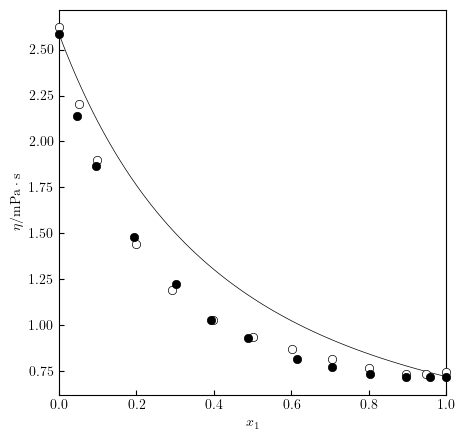

In [205]:
plt.rcParams['text.usetex'] = True
plt.figure(figsize=(5,5))
plt.tick_params(direction='in')
plt.scatter(x1exp_can, dvisexp_can, facecolors="white", edgecolors="black", clip_on=False, zorder=10, linewidth=0.5)
plt.scatter(x1exp, dvisexp, color="black", clip_on=False, zorder=10, linewidth=0.5)
plt.plot(X[0], dvismix, color="black", linewidth=0.5)
plt.xlim([0.0, 1.0])
plt.xlabel(r"$x_{1}$")
plt.ylabel(r"$\eta/\mathrm{mPa}\cdot\mathrm{s}$")
plt.savefig("dvis_mix.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [206]:
n = len(x1exp)
Xexp = np.array([x1exp, 1-x1exp])
dvismix = np.zeros_like(x1exp)
for i in range(n):
    dvismix[i] = dvismAsc(mix, T, P, Xexp[:,i], comp1Asc.x, comp2Asc.x, "Wilson", Wilson94/8.314)

AAPD = 1/n*np.sum(abs(dvismix-dvisexp)/dvisexp)
print("AAPD/%: ", AAPD)

AAPD/%:  0.1448035936472448


In [207]:
X = np.array([np.linspace(0.00, 1.00, num=101), 
              np.linspace(1.00, 0.00, num=101)])
n = len(X[0])
from phasepy.equilibrium import bubbleTy
dg = np.array([[0, Wilson50[0]], 
               [Wilson50[1], 0]]) 
mix.wilson(dg)
eos = prsveos(mix, mixrule='mhv_wilson')
p = 0.5000
T0 = 380
Ypr50 = np.zeros_like(X)
Tpr50 = np.zeros_like(X[0])
for i in range(n):
    Ypr50[:,i], Tpr50[i] = bubbleTy(X[:,i], T0, X[:,i], p, eos)

In [208]:
p = 0.7500
T0 = 380
dg = np.array([[0, Wilson75[0]], 
               [Wilson75[1], 0]]) 
mix.wilson(dg)
eos = prsveos(mix, mixrule='mhv_wilson')
Ypr75 = np.zeros_like(X)
Tpr75 = np.zeros_like(X[0])
for i in range(n):
    Ypr75[:,i], Tpr75[i] = bubbleTy(X[:,i], T0, X[:,i], p, eos)

In [209]:
p = 0.9400
T0 = 380
dg = np.array([[0, Wilson94[0]/8.314], 
               [Wilson94[1]/8.314, 0]]) 
mix.wilson(dg)
eos = prsveos(mix, mixrule='mhv_wilson')
Ypr94 = np.zeros_like(X)
Tpr94 = np.zeros_like(X[0])
for i in range(n):
    Ypr94[:,i], Tpr94[i] = bubbleTy(X[:,i], T0, X[:,i], p, eos)

In [210]:
p = 1.01300
T0 = 380
dg = np.array([[0, Wilson94[0]/8.314], 
               [Wilson94[1]/8.314, 0]]) 
mix.wilson(dg)
eos = prsveos(mix, mixrule='mhv_wilson')
Ypr101 = np.zeros_like(X)
Tpr101 = np.zeros_like(X[0])
for i in range(n):
    Ypr101[:,i], Tpr101[i] = bubbleTy(X[:,i], T0, X[:,i], p, eos)

In [211]:
def azeotrope(mixture, p, T0, model, paramsgE):
    from phasepy import prsveos
    dg = np.array([[0.0, paramsgE[0]], 
                 [paramsgE[1], 0.0]]) 
    if model=="Wilson":
        mixture.wilson(dg)
        eos = prsveos(mixture, 'mhv_wilson')
    elif model=="NRTL":
        alpha = np.array([[0.0, 0.3], 
                     [0.3, 0.0]])
        mixture.NRTL(alpha, dg)
        eos = prsveos(mixture, 'mhv_nrtl')
    elif model=="UNIQUAC":
        mixture.uniquac(dg)
        eos = prsveos(mixture, 'mhv_uniquac')
    X0 = np.array([0.5, 0.5])
    Y0 = X0
    from phasepy.equilibrium import bubbleTy
    Y, T = bubbleTy(Y0, T0, X0, p, eos)
    while abs(Y[0]-X0[0])>=1.0e-04:
        X0 = Y
        Y0 = X0
        Y, T = bubbleTy(Y0, T0, X0, p, eos)
    return Y, T

In [212]:
T0 = 375
p = 0.5000
Zaz50, Taz50 = azeotrope(mix, p, T0, "Wilson", Wilson50)
print("Azeotropic conditions at p=", p, "kPa")
print("==================================================")
print("Comp.:", Zaz50)
print("Temp./K:", Taz50)

Azeotropic conditions at p= 0.5 kPa
Comp.: [0.38532287 0.61467713]
Temp./K: 368.8953615245623


In [213]:
T0 = 382
p = 0.7500
Zaz75, Taz75 = azeotrope(mix, p, T0, "Wilson", Wilson75)
print("Azeotropic conditions at p=", p, "kPa")
print("==================================================")
print("Comp.:", Zaz75)
print("Temp./K:", Taz75)

Azeotropic conditions at p= 0.75 kPa
Comp.: [0.32108293 0.67891707]
Temp./K: 380.1045028115491


In [214]:
T0 = 388
p = 0.9400
Zaz94, Taz94 = azeotrope(mix, p, T0, "Wilson", Wilson94/8.314)
print("Azeotropic conditions at p=", p, "kPa")
print("==================================================")
print("Comp.:", Zaz94)
print("Temp./K:", Taz94)

Azeotropic conditions at p= 0.94 kPa
Comp.: [0.28002695 0.71997305]
Temp./K: 386.6939901477426


In [215]:
T0 = 390
p = 1.0130
Zaz101, Taz101 = azeotrope(mix, p, T0, "Wilson", Wilson94/8.314)
print("Azeotropic conditions at p=", p, "kPa")
print("==================================================")
print("Comp.:", Zaz101)
print("Temp./K:", Taz101)

Azeotropic conditions at p= 1.013 kPa
Comp.: [0.27223732 0.72776268]
Temp./K: 388.8589231272309


In [216]:
Taz = np.array([Taz50, Taz75, Taz94, Taz101])
Zaz = np.array([Zaz50[0], Zaz75[0], Zaz94[0], Zaz101[0]])

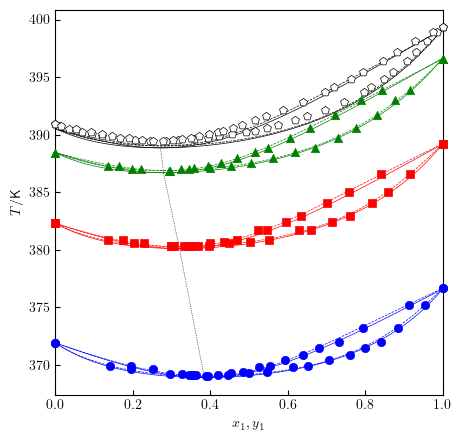

In [217]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
fig = plt.subplots(figsize=(5,5))
plt.tick_params(direction='in')
plt.scatter(Xexp50[0], Texp50, color='blue', clip_on=False, zorder=10, linewidth=0.5)
plt.scatter(Yexp50[0], Texp50, color='blue', clip_on=False, zorder=10, linewidth=0.5)
plt.scatter(Xexp75[0], Texp75, marker='s', color='red', clip_on=False, zorder=10, linewidth=0.5)
plt.scatter(Yexp75[0], Texp75, marker='s', color='red', clip_on=False, zorder=10, linewidth=0.5)
plt.scatter(Xexp94[0], Texp94, marker='^', color='green', clip_on=False, zorder=10, linewidth=0.5)
plt.scatter(Yexp94[0], Texp94, marker='^', color='green', clip_on=False, zorder=10, linewidth=0.5)
plt.scatter(Xexp101[0], Texp101, marker='p', facecolors="white", edgecolors='black', clip_on=False, zorder=10, linewidth=0.5)
plt.scatter(Yexp101[0], Texp101, marker='p', facecolors="white", edgecolors='black', clip_on=False, zorder=10, linewidth=0.5)
plt.plot(x1, T_50, color='blue', linewidth=0.5, linestyle="dashed")
plt.plot(y1_50, T_50, color='blue', linewidth=0.5, linestyle="dashed")
plt.plot(x1, T_75, color='red', linewidth=0.5, linestyle="dashed")
plt.plot(y1_75, T_75, color='red', linewidth=0.5, linestyle="dashed")
plt.plot(x1, T_94, color='green', linewidth=0.5, linestyle="dashed")
plt.plot(y1_94, T_94, color='green', linewidth=0.5, linestyle="dashed")
plt.plot(x1, T_101, color='black', linewidth=0.5, linestyle="dashed")
plt.plot(y1_101, T_101, color='black', linewidth=0.5, linestyle="dashed")
plt.plot(X[0], Tpr50, color='blue', linewidth=0.5)
plt.plot(Ypr50[0], Tpr50, color='blue', linewidth=0.5)
plt.plot(X[0], Tpr75, color='red', linewidth=0.5)
plt.plot(Ypr75[0], Tpr75, color='red', linewidth=0.5)
plt.plot(X[0], Tpr94, color='green', linewidth=0.5)
plt.plot(Ypr94[0], Tpr94, color='green', linewidth=0.5)
plt.plot(X[0], Tpr101, color='black', linewidth=0.5)
plt.plot(Ypr101[0], Tpr101, color='black', linewidth=0.5)
plt.plot(Zaz, Taz, color='black', linewidth=0.5, linestyle="dotted")
plt.xlim([0, 1.0])
plt.xlabel(r'$x_{1}, y_{1}$')
plt.ylabel(r'$T$/K')
plt.savefig("VLE.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [218]:
# Py Bubble-point calculations with PR + MHV:
from phasepy.equilibrium import bubblePy
Yprexp = np.zeros_like(Xexp50)
pprexp = np.zeros_like(Xexp50[0])
dg = np.array([[0, Wilson50[0]], 
               [Wilson50[1], 0]]) 
mix.wilson(dg)
eos = prsveos(mix, mixrule='mhv_wilson')
m = len(Xexp50[0])
for i in range(m):
    Yprexp[:,i], pprexp[i] = bubblePy(Yexp50[:,i], pexp50[i]/100, Xexp50[:,i], Texp50[i], eos)

dppr50 = pprexp*100-pexp50
dy1pr50 = Yprexp[0]-Yexp50[0]
AADp = 1/len(pexp50)*np.sum(abs(pprexp*100-pexp50))
AADy1 = 1/len(pexp50)*np.sum(abs(Yprexp[0]-Yexp50[0]))
print("Bubble-point statistics at p=", pexp50[0], "kPa")
print("===========================================================")
print("AADp/kPa", AADp)
print("AADy1", AADy1)

Bubble-point statistics at p= 50 kPa
AADp/kPa 0.2641636617534816
AADy1 0.004807123588070344


In [219]:
Yprexp = np.zeros_like(Xexp75)
pprexp = np.zeros_like(Xexp75[0])
dg = np.array([[0, Wilson75[0]], 
               [Wilson75[1], 0]]) 
mix.wilson(dg)
eos = prsveos(mix, mixrule='mhv_wilson')
m = len(Xexp75[0])
for i in range(m):
    Yprexp[:,i], pprexp[i] = bubblePy(Yexp75[:,i], pexp75[i]/100, Xexp75[:,i], Texp75[i], eos)

dppr75 = pprexp*100-pexp75
dy1pr75 = Yprexp[0]-Yexp75[0]
AADp = 1/len(pexp75)*np.sum(abs(pprexp*100-pexp75))
AADy1 = 1/len(pexp75)*np.sum(abs(Yprexp[0]-Yexp75[0]))
print("Bubble-point statistics at p=", pexp75[0], "kPa")
print("===========================================================")
print("AADp/kPa", AADp)
print("AADy1", AADy1)

Bubble-point statistics at p= 75 kPa
AADp/kPa 0.4140467531062147
AADy1 0.00449239800352792


In [220]:
Yprexp = np.zeros_like(Xexp94)
pprexp = np.zeros_like(Xexp94[0])
dg = np.array([[0, Wilson94[0]/8.314], 
               [Wilson94[1]/8.314, 0]]) 
mix.wilson(dg)
eos = prsveos(mix, mixrule='mhv_wilson')
m = len(Xexp94[0])
for i in range(m):
    Yprexp[:,i], pprexp[i] = bubblePy(Yexp94[:,i], pexp94[i]/100, Xexp94[:,i], Texp94[i], eos)

dppr94 = pprexp*100-pexp94
dy1pr94 = Yprexp[0]-Yexp94[0]
AADp = 1/len(pexp94)*np.sum(abs(pprexp*100-pexp94))
AADy1 = 1/len(pexp94)*np.sum(abs(Yprexp[0]-Yexp94[0]))
print("Bubble-point statistics at p=", pexp94[0], "kPa")
print("===========================================================")
print("AADp/kPa", AADp)
print("AADy1", AADy1)

Bubble-point statistics at p= 94 kPa
AADp/kPa 0.4636548449656183
AADy1 0.003638289305811194


In [221]:
Yprexp = np.zeros_like(Xexp101)
pprexp = np.zeros_like(Xexp101[0])
dg = np.array([[0, Wilson94[0]/8.314], 
               [Wilson94[1]/8.314, 0]]) 
mix.wilson(dg)
eos = prsveos(mix, mixrule='mhv_wilson')
m = len(Xexp101[0])
for i in range(m):
    Yprexp[:,i], pprexp[i] = bubblePy(Yexp101[:,i], pexp101[i]/100, Xexp101[:,i], Texp101[i], eos)

dppr101 = pprexp*100-pexp101
dy1pr101 = Yprexp[0]-Yexp101[0]
AADp = 1/len(pexp101)*np.sum(abs(pprexp*100-pexp101))
AADy1 = 1/len(pexp101)*np.sum(abs(Yprexp[0]-Yexp101[0]))
print("Bubble-point statistics at p=", pexp101[0], "kPa")
print("===========================================================")
print("AADp/kPa", AADp)
print("AADy1", AADy1)

Bubble-point statistics at p= 101.3 kPa
AADp/kPa 1.8849114408354906
AADy1 0.004953982921261714


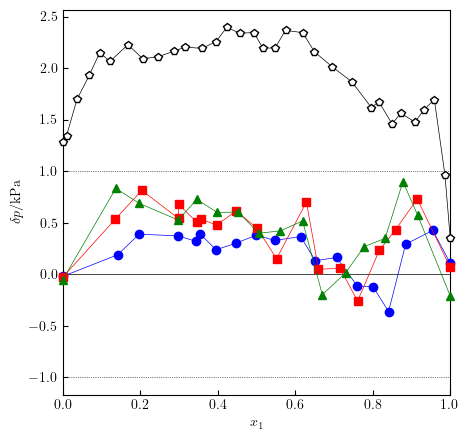

In [222]:
plt.rcParams['text.usetex'] = True
fig = plt.subplots(figsize=(5,5))
plt.tick_params(direction='in')
plt.plot(Xexp50[0], dppr50, marker="o", color='blue', clip_on=False, zorder=10, linewidth=0.5)
plt.plot(Xexp75[0], dppr75, marker='s', color='red', clip_on=False, zorder=10, linewidth=0.5)
plt.plot(Xexp94[0], dppr94, marker='^', color='green', clip_on=False, zorder=10, linewidth=0.5)
plt.plot(Xexp101[0], dppr101, marker='p', mfc="white", mec='black', color="black", clip_on=False, zorder=10, linewidth=0.5)
plt.xlim([0, 1.0])
plt.axhline(y=1.0, linestyle="dotted", color="black", linewidth=0.5)
plt.axhline(y=0.0, color="black", linewidth=0.5)
plt.axhline(y=-1.0, linestyle="dotted", color="black", linewidth=0.5)
plt.xlabel(r'$x_{1}$')
plt.ylabel(r'$\delta p/\mathrm{kPa}$')
plt.savefig("py1_dPpr.pdf", format="pdf", bbox_inches="tight")
plt.show()

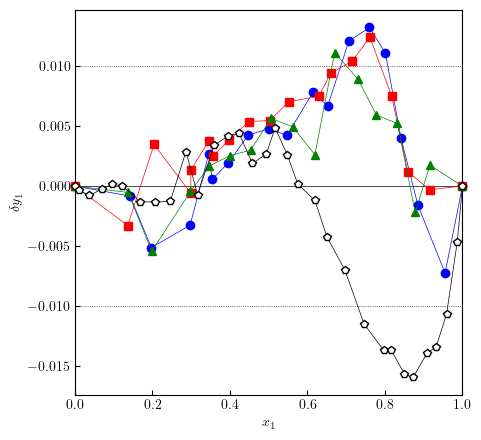

In [223]:
plt.rcParams['text.usetex'] = True
fig = plt.subplots(figsize=(5,5))
plt.tick_params(direction='in')
plt.plot(Xexp50[0], dy1pr50, marker="o", color='blue', clip_on=False, zorder=10, linewidth=0.5)
plt.plot(Xexp75[0], dy1pr75, marker='s', color='red', clip_on=False, zorder=10, linewidth=0.5)
plt.plot(Xexp94[0], dy1pr94, marker='^', color='green', clip_on=False, zorder=10, linewidth=0.5)
plt.plot(Xexp101[0], dy1pr101, marker='p', mfc="white", mec='black', color="black", clip_on=False, zorder=10, linewidth=0.5)
plt.xlim([0, 1.0])
plt.axhline(y=0.01, linestyle="dotted", color="black", linewidth=0.5)
plt.axhline(y=0.0, color="black", linewidth=0.5)
plt.axhline(y=-0.01, linestyle="dotted", color="black", linewidth=0.5)
plt.xlabel(r'$x_{1}$')
plt.ylabel(r'$\delta y_{1}$')
plt.savefig("py1_dy1pr.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [224]:
# Ty Bubble-point calculations with PR + MHV:
from phasepy.equilibrium import bubbleTy
Yprexp = np.zeros_like(Xexp50)
Tprexp = np.zeros_like(Xexp50[0])
dg = np.array([[0, Wilson50[0]], 
               [Wilson50[1], 0]]) 
mix.wilson(dg)
eos = prsveos(mix, mixrule='mhv_wilson')
m = len(Xexp50[0])
for i in range(m):
    Yprexp[:,i], Tprexp[i] = bubbleTy(Yexp50[:,i], Texp50[i], Xexp50[:,i], pexp50[i]/100, eos)

dTpr50 = Tprexp-Texp50
dy1pr50 = Yprexp[0]-Yexp50[0]
AADT = 1/len(pexp50)*np.sum(abs(Tprexp-Texp50))
AADy1 = 1/len(pexp50)*np.sum(abs(Yprexp[0]-Yexp50[0]))
print("Bubble-point statistics at p=", pexp50[0], "kPa")
print("===========================================================")
print("AADT/K", AADT)
print("AADy1", AADy1)

Bubble-point statistics at p= 50 kPa
AADT/K 0.14065481237096383
AADy1 0.004850467566042346


In [225]:
Yprexp = np.zeros_like(Xexp75)
Tprexp = np.zeros_like(Xexp75[0])
dg = np.array([[0, Wilson75[0]], 
               [Wilson75[1], 0]]) 
mix.wilson(dg)
eos = prsveos(mix, mixrule='mhv_wilson')
m = len(Xexp75[0])
for i in range(m):
    Yprexp[:,i], Tprexp[i] = bubbleTy(Yexp75[:,i], Texp75[i], Xexp75[:,i], pexp75[i]/100, eos)

dTpr75 = Tprexp-Texp75
dy1pr75 = Yprexp[0]-Yexp75[0]
AADT = 1/len(pexp75)*np.sum(abs(Tprexp-Texp75))
AADy1 = 1/len(pexp75)*np.sum(abs(Yprexp[0]-Yexp75[0]))
print("Bubble-point statistics at p=", pexp75[0], "kPa")
print("===========================================================")
print("AADT/K", AADT)
print("AADy1", AADy1)

Bubble-point statistics at p= 75 kPa
AADT/K 0.15668515741582137
AADy1 0.004585104838428898


In [226]:
Yprexp = np.zeros_like(Xexp94)
Tprexp = np.zeros_like(Xexp94[0])
dg = np.array([[0, Wilson94[0]/8.314], 
               [Wilson94[1]/8.314, 0]]) 
mix.wilson(dg)
eos = prsveos(mix, mixrule='mhv_wilson')
m = len(Xexp94[0])
for i in range(m):
    Yprexp[:,i], Tprexp[i] = bubbleTy(Yexp94[:,i], Texp94[i], Xexp94[:,i], pexp94[i]/100, eos)

dTpr94 = Tprexp-Texp94
dy1pr94 = Yprexp[0]-Yexp94[0]
AADT = 1/len(pexp94)*np.sum(abs(Tprexp-Texp94))
AADy1 = 1/len(pexp94)*np.sum(abs(Yprexp[0]-Yexp94[0]))
print("Bubble-point statistics at p=", pexp94[0], "kPa")
print("===========================================================")
print("AADT/K", AADT)
print("AADy1", AADy1)

Bubble-point statistics at p= 94 kPa
AADT/K 0.14782617861768652
AADy1 0.0036700733694514866


In [227]:
Yprexp = np.zeros_like(Xexp101)
Tprexp = np.zeros_like(Xexp101[0])
dg = np.array([[0, Wilson94[0]/8.314], 
               [Wilson94[1]/8.314, 0]]) 
mix.wilson(dg)
eos = prsveos(mix, mixrule='mhv_wilson')
m = len(Xexp101[0])
for i in range(m):
    Yprexp[:,i], Tprexp[i] = bubbleTy(Yexp101[:,i], Texp101[i], Xexp101[:,i], pexp101[i]/100, eos)

dTpr101 = Tprexp-Texp101
dy1pr101 = Yprexp[0]-Yexp101[0]
AADT = 1/len(pexp101)*np.sum(abs(Tprexp-Texp101))
AADy1 = 1/len(pexp101)*np.sum(abs(Yprexp[0]-Yexp101[0]))
print("Bubble-point statistics at p=", pexp101[0], "kPa")
print("===========================================================")
print("AADT/K", AADT)
print("AADy1", AADy1)

Bubble-point statistics at p= 101.3 kPa
AADT/K 0.5586657830251038
AADy1 0.004959223723810285


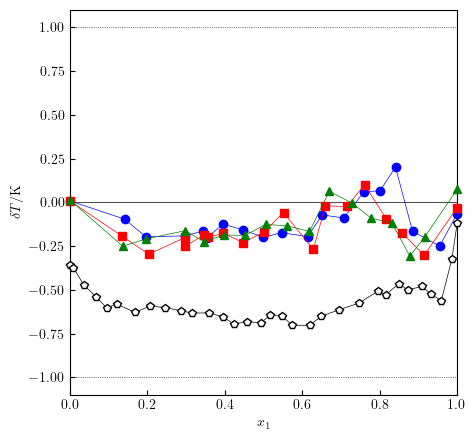

In [228]:
plt.rcParams['text.usetex'] = True
fig = plt.subplots(figsize=(5,5))
plt.tick_params(direction='in')
plt.plot(Xexp50[0], dTpr50, marker="o", color='blue', clip_on=False, zorder=10, linewidth=0.5)
plt.plot(Xexp75[0], dTpr75, marker='s', color='red', clip_on=False, zorder=10, linewidth=0.5)
plt.plot(Xexp94[0], dTpr94, marker='^', color='green', clip_on=False, zorder=10, linewidth=0.5)
plt.plot(Xexp101[0], dTpr101, marker='p', mfc="white", mec='black', color="black", clip_on=False, zorder=10, linewidth=0.5)
plt.xlim([0, 1.0])
plt.axhline(y=1.0, linestyle="dotted", color="black", linewidth=0.5)
plt.axhline(y=0.0, color="black", linewidth=0.5)
plt.axhline(y=-1.0, linestyle="dotted", color="black", linewidth=0.5)
plt.xlabel(r'$x_{1}$')
plt.ylabel(r'$\delta T/\mathrm{K}$')
plt.savefig("Ty1_dTpr.pdf", format="pdf", bbox_inches="tight")
plt.show()

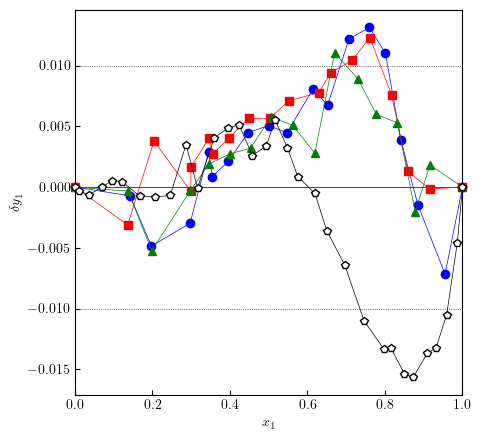

In [229]:
plt.rcParams['text.usetex'] = True
fig = plt.subplots(figsize=(5,5))
plt.tick_params(direction='in')
plt.plot(Xexp50[0], dy1pr50, marker="o", color='blue', clip_on=False, zorder=10, linewidth=0.5)
plt.plot(Xexp75[0], dy1pr75, marker='s', color='red', clip_on=False, zorder=10, linewidth=0.5)
plt.plot(Xexp94[0], dy1pr94, marker='^', color='green', clip_on=False, zorder=10, linewidth=0.5)
plt.plot(Xexp101[0], dy1pr101, marker='p', mfc="white", mec='black', color="black", clip_on=False, zorder=10, linewidth=0.5)
plt.xlim([0, 1.0])
plt.axhline(y=0.01, linestyle="dotted", color="black", linewidth=0.5)
plt.axhline(y=0.0, color="black", linewidth=0.5)
plt.axhline(y=-0.01, linestyle="dotted", color="black", linewidth=0.5)
plt.xlabel(r'$x_{1}$')
plt.ylabel(r'$\delta y_{1}$')
plt.savefig("Ty1_dy1pr.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [230]:
IFT = pd.read_excel("DEC-1butol.xlsx", sheet_name="IFT")
x1exp = IFT['x1'].to_numpy()
IFTexp = IFT['st/mN.m'].to_numpy()
IFT.head(n=4)

,x1,st/mN.m
0,0.000,24.37
1,0.045,24.49
2,0.092,24.68
3,0.194,24.97


In [231]:
def Chunxi_an(component1, component2, T, paramsgE, paramsdgE, stexp):
    import sympy as sp
    x1 = sp.symbols('x1')
    vlsat1 = component1.vlrackett(T)
    vlsat2 = component2.vlrackett(T)
    A12 = vlsat2/vlsat1*np.exp(-paramsgE[0]/8.314/T)
    A21 = vlsat1/vlsat2*np.exp(-paramsgE[1]/8.314/T)
    dA12 = -A12/8.314/T*paramsdgE[0]
    dA21 = -A21/8.314/T*paramsdgE[1]
    st = x1*stexp[-1]+(1-x1)*stexp[0]-8.314*T*(x1*(1-x1)/(x1+(1-x1)*A12)*dA12+(1-x1)*x1/(x1*A21+(1-x1))*dA21)*1000
    dst = sp.diff(st, x1)
    d2st = sp.diff(dst, x1)
    from scipy.optimize import fsolve
    from sympy import lambdify
    fun1 = sp.lambdify(x1, dst)
    xan = fsolve(fun1, [0.6])
    return xan

In [232]:
import sympy as sp
xan = Chunxi_an(chem1, chem2, T, Wilson94, paramsChunxi.x, IFTexp)

In [233]:
stan = Chunxist(xan[0], chem1, chem2, IFTexp, T, Wilson94, paramsChunxi.x)

In [234]:
x1 = np.linspace(0.00001, 0.99999, num = 100)
n = len(x1)
stmix = np.zeros_like(x1)
for i in range(n):
    stmix[i] = Chunxist(x1[i], chem1, chem2, IFTexp, T, Wilson94, paramsChunxi.x)

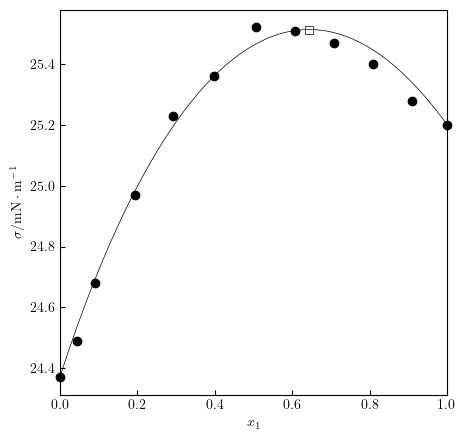

In [235]:
plt.rcParams['text.usetex'] = True
fig = plt.subplots(figsize=(5,5))
plt.tick_params(direction='in')
plt.plot(x1, stmix, color='black', linewidth=0.5)
plt.scatter(xan, stan, marker="s", edgecolors="black", facecolors="white", linewidth=0.5)
plt.scatter(x1exp, IFTexp, color="black", clip_on=False, zorder=10)
plt.xlim([0.0, 1.0])
plt.xlabel(r"$x_{1}$")
plt.ylabel(r"$\sigma/\mathrm{mN}\cdot \mathrm{m}^{-1}$")
plt.savefig("stmix_chunxi.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [236]:
xan

array([0.64360546])

In [237]:
def adsorption(mixture, component1, component2, T, model, paramsgE, paramsdgE, stexp):
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    
    gExc = gE(mixture, model, n, T).evalf(subs={a0: paramsgE[0]/8.314, a1: paramsgE[1]/8.314, a2: paramsgE[2]/8.314, a3: paramsgE[3]/8.314, a4: paramsgE[4]/8.314})
    dgExc = dgE(mixture, model, n, T).evalf(subs={a0: paramsgE[0]/8.314, a1: paramsgE[1]/8.314, a2: paramsgE[2]/8.314, a3: paramsgE[3]/8.314, a4: paramsgE[4]/8.314})
    lngam1 = gExc+(1-x)*dgExc
    lngam2 = gExc-x*dgExc
    dlngam1 = sp.diff(lngam1, x)
    dlngam2 = sp.diff(lngam2, x)
    vlsat1 = component1.vlrackett(T)
    vlsat2 = component2.vlrackett(T)
    A12 = vlsat2/vlsat1*np.exp(-paramsgE[0]/8.314/T)
    A21 = vlsat1/vlsat2*np.exp(-paramsgE[1]/8.314/T)
    dA12 = -A12/8.314/T*paramsdgE[0]
    dA21 = -A21/8.314/T*paramsdgE[1]
    st = x*stexp[-1]+(1-x)*stexp[0]-8.314*T*(x*(1-x)/(x+(1-x)*A12)*dA12+(1-x)*x/(x*A21+(1-x))*dA21)*1000
    GA = -sp.diff(st/1000, x)*x/8.314/T/(1+x*dlngam1)
    
    return GA

In [238]:
def lngamma1(mixture, component1, component2, T, model, paramsgE, paramsdgE, stexp):
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    paramsgE = paramsgE/8.314
    gExc = gE(mixture, model, n, T).evalf(subs={a0: paramsgE[0], a1: paramsgE[1], a2: paramsgE[2], a3: paramsgE[3], a4: paramsgE[4]})
    dgExc = dgE(mixture, model, n, T).evalf(subs={a0: paramsgE[0], a1: paramsgE[1], a2: paramsgE[2], a3: paramsgE[3], a4: paramsgE[4]})
    lngam1 = gExc+(1-x)*dgExc
    lngam2 = gExc-x*dgExc

    return lngam1

In [239]:
def dst(mixture, component1, component2, T, model, paramsgE, paramsdgE, stexp):
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    
    gExc = gE(mixture, model, n, T).evalf(subs={a0: paramsgE[0]/8.314, a1: paramsgE[1]/8.314, a2: paramsgE[2]/8.314, a3: paramsgE[3]/8.314, a4: paramsgE[4]/8.314})
    dgExc = dgE(mixture, model, n, T).evalf(subs={a0: paramsgE[0]/8.314, a1: paramsgE[1]/8.314, a2: paramsgE[2]/8.314, a3: paramsgE[3]/8.314, a4: paramsgE[4]/8.314})
    lngam1 = gExc+(1-x)*dgExc
    lngam2 = gExc-x*dgExc
    dlngam1 = sp.diff(lngam1, x)
    dlngam2 = sp.diff(lngam2, x)
    vlsat1 = component1.vlrackett(T)
    vlsat2 = component2.vlrackett(T)
    A12 = vlsat2/vlsat1*np.exp(-paramsgE[0]/8.314/T)
    A21 = vlsat1/vlsat2*np.exp(-paramsgE[1]/8.314/T)
    dA12 = -A12/8.314/T*paramsdgE[0]
    dA21 = -A21/8.314/T*paramsdgE[1]
    st = x*stexp[-1]+(1-x)*stexp[0]-8.314*T*(x*(1-x)/(x+(1-x)*A12)*dA12+(1-x)*x/(x*A21+(1-x))*dA21)*1000
    dst = sp.diff(st/1000, x)
    
    return dst

In [240]:
def dlngamma1(mixture, component1, component2, T, model, paramsgE, paramsdgE, stexp):
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    paramsgE = paramsgE/8.314
    gExc = gE(mixture, model, n, T).evalf(subs={a0: paramsgE[0], a1: paramsgE[1], a2: paramsgE[2], a3: paramsgE[3], a4: paramsgE[4]})
    dgExc = dgE(mixture, model, n, T).evalf(subs={a0: paramsgE[0], a1: paramsgE[1], a2: paramsgE[2], a3: paramsgE[3], a4: paramsgE[4]})
    lngam1 = gExc+(1-x)*dgExc
    lngam2 = gExc-x*dgExc
    deriv = sp.diff(lngam1, x)
    return deriv

In [241]:
def lngamma2(mixture, component1, component2, T, model, paramsgE, paramsdgE, stexp):
    import sympy as sp
    x = sp.symbols('x')
    a0 = sp.symbols('a0') 
    a1 = sp.symbols('a1')
    a2 = sp.symbols('a2')
    a3 = sp.symbols('a3')
    a4 = sp.symbols('a4')
    paramsgE = paramsgE/8.314
    gExc = gE(mixture, model, n, T).evalf(subs={a0: paramsgE[0], a1: paramsgE[1], a2: paramsgE[2], a3: paramsgE[3], a4: paramsgE[4]})
    dgExc = dgE(mixture, model, n, T).evalf(subs={a0: paramsgE[0], a1: paramsgE[1], a2: paramsgE[2], a3: paramsgE[3], a4: paramsgE[4]})
    lngam1 = gExc+(1-x)*dgExc
    lngam2 = gExc-x*dgExc

    return lngam2

In [242]:
import sympy as sp
x = sp.symbols('x')

In [243]:
GA = np.zeros_like(x1)
lngam1 = np.zeros_like(x1)
deriv1 = np.zeros_like(x1)
derivst = np.zeros_like(x1)
for i in range(n):
    GA[i] = adsorption(mix, chem1, chem2, T, "Wilson", Wilson94, paramsChunxi.x, IFTexp).evalf(subs={x: x1[i]})
    lngam1[i] = lngamma1(mix, chem1, chem2, T, "Wilson", Wilson94, paramsChunxi.x, IFTexp).evalf(subs={x: x1[i]})
    deriv1[i] = dlngamma1(mix, chem1, chem2, T, "Wilson", Wilson94, paramsChunxi.x, IFTexp).evalf(subs={x: x1[i]})
    derivst[i] = dst(mix, chem1, chem2, T, "Wilson", Wilson94, paramsChunxi.x, IFTexp).evalf(subs={x: x1[i]})

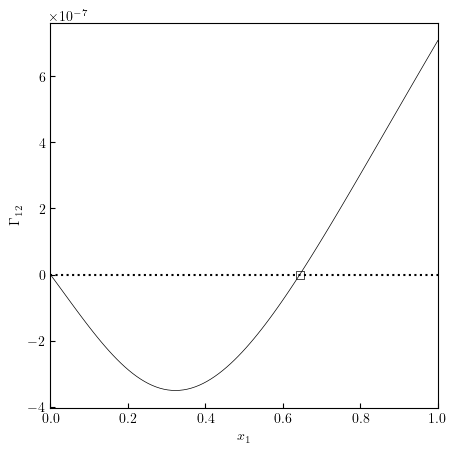

In [244]:
plt.rcParams['text.usetex'] = True
fig = plt.subplots(figsize=(5,5))
plt.tick_params(direction='in')
plt.plot(x1, GA, color='black', linewidth=0.5)
plt.scatter(xan, 0.0, facecolors="white", edgecolors="black", marker="s", linewidth=0.5)
plt.axhline(y=0.0, color="black", linestyle="dotted")
plt.xlim([0.0, 1.0])
plt.xlabel(r"$x_{1}$")
plt.ylabel(r"$\Gamma_{12}$")
plt.savefig("GA_wilson.pdf", format="pdf", bbox_inches="tight")
plt.show()

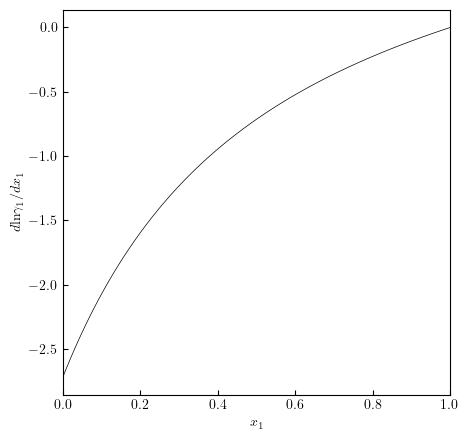

In [245]:
plt.rcParams['text.usetex'] = True
fig = plt.subplots(figsize=(5,5))
plt.tick_params(direction='in')
plt.plot(x1, deriv1, color='black', linewidth=0.5)
plt.xlim([0.0, 1.0])
plt.xlabel(r"$x_{1}$")
plt.ylabel(r"$d\mathrm{ln}\gamma_{1}/dx_{1}$")
plt.show()

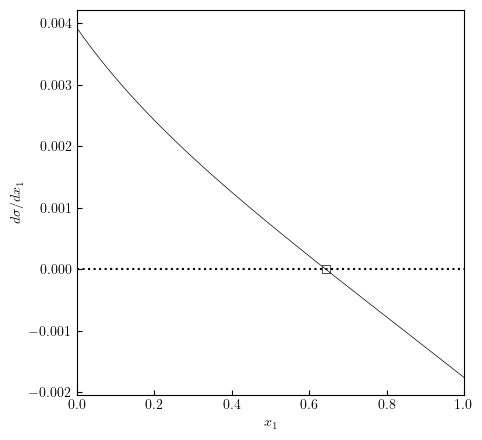

In [246]:
plt.rcParams['text.usetex'] = True
fig = plt.subplots(figsize=(5,5))
plt.tick_params(direction='in')
plt.plot(x1, derivst, color='black', linewidth=0.5)
plt.xlim([0.0, 1.0])
plt.scatter(xan, 0.0, facecolors="white", edgecolors="black", marker="s", linewidth=0.5)
plt.axhline(y=0.0, color="black", linestyle="dotted")
plt.xlabel(r"$x_{1}$")
plt.ylabel(r"$d\sigma/dx_{1}$")
plt.show()

In [247]:
array = np.transpose(np.array([x1, stmix/1000, lngam1, lngam2]))

NameError: name 'lngam2' is not defined

In [ ]:
df = pd.DataFrame(array, columns=['x1', 'stmix', 'lngam1', 'lngam2'])
excel_filepath = 'adsorption_DEC+butol.xlsx'
df.to_excel(excel_filepath, index=False)